# 03 · Visualization Pack (Deliverable C)
Twelve figures, saved to `../figures/` under the required names, plus `figure_captions.md`. Every figure is produced by the code below.
Figures 10-12 use a quick model trained only on the **train** file (80/20 split, seed 42); the full modeling write-up is Deliverable D.

## Cell 1 · Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Cell 2 · Read the data and check the paths

In [2]:
TRAIN_RAW_PATH = "../data/raw/crop_yield_train.csv"          # raw tables (figures 1-2)
WEATHER_RAW_PATH = "../data/raw/regional_weather.csv"
PRICE_RAW_PATH = "../data/raw/market_prices.csv"
MASTER_TRAIN_PATH = "../data/processed/master_train.csv"     # outputs of notebook 01
WEATHER_CLEAN_PATH = "../data/processed/weather_clean.csv"
PRICE_CLEAN_PATH = "../data/processed/prices_clean.csv"
FIG_DIR = "../figures"

paths = [TRAIN_RAW_PATH, WEATHER_RAW_PATH, PRICE_RAW_PATH, MASTER_TRAIN_PATH, WEATHER_CLEAN_PATH, PRICE_CLEAN_PATH]
for p in paths:
    print("FOUND  " if os.path.exists(p) else "MISSING", p)
assert all(os.path.exists(p) for p in paths), "Run notebook 01 first (it creates the processed files)"
os.makedirs(FIG_DIR, exist_ok=True)

train_raw = pd.read_csv(TRAIN_RAW_PATH)
weather_raw = pd.read_csv(WEATHER_RAW_PATH)
prices_raw = pd.read_csv(PRICE_RAW_PATH)
df = pd.read_csv(MASTER_TRAIN_PATH)
weather_clean = pd.read_csv(WEATHER_CLEAN_PATH)
prices_clean = pd.read_csv(PRICE_CLEAN_PATH)
df["revenue_birr_per_ha"] = df.yield_tons_per_ha * 10 * df.price_birr_per_quintal

print()
print("raw train:", train_raw.shape, "| raw weather:", weather_raw.shape, "| raw prices:", prices_raw.shape)
print("master_train:", df.shape, "| weather_clean:", weather_clean.shape, "| prices_clean:", prices_clean.shape)

FOUND   ../data/raw/crop_yield_train.csv
FOUND   ../data/raw/regional_weather.csv
FOUND   ../data/raw/market_prices.csv
FOUND   ../data/processed/master_train.csv
FOUND   ../data/processed/weather_clean.csv
FOUND   ../data/processed/prices_clean.csv

raw train: (15090, 15) | raw weather: (232, 6) | raw prices: (100, 4)
master_train: (15000, 26) | weather_clean: (240, 8) | prices_clean: (100, 4)


## Cell 3 · One style for the whole pack (colour-blind-safe palettes) and a save helper

In [3]:
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 15, "axes.titleweight": "bold", "axes.labelsize": 13,
                     "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12, "legend.frameon": True,
                     "axes.spines.top": False, "axes.spines.right": False})

# Okabe-Ito for regions, Paul Tol "bright/high-contrast" for crops - both colour-blind safe
REGION_COLORS = {"Amhara": "#0072B2", "Oromia": "#E69F00", "SNNPR": "#009E73", "Somali": "#D55E00", "Tigray": "#CC79A7"}
CROP_COLORS = {"barley": "#4477AA", "maize": "#228833", "sorghum": "#AA3377", "teff": "#EE6677", "wheat": "#DDAA33"}
C_RAW, C_CLEAN = "#D55E00", "#0072B2"          # before / after cleaning
C_WEATHER, C_OTHER = "#D55E00", "#0072B2"      # weather-derived vs other features
CROPS = sorted(CROP_COLORS)
REGIONS = sorted(REGION_COLORS)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

WEATHER_DERIVED = ["season_mean_temp_c", "season_rain_total_mm", "season_extreme_heat_days", "season_temp_dev_c", "aridity_ratio"]
NICE = {"yield_tons_per_ha": "Yield (t/ha)", "survey_year": "Survey year", "altitude_m": "Altitude (m)", "rainfall_mm_season": "Plot-reported rainfall (mm)",
        "farm_size_ha": "Farm size (ha)", "fertilizer_kg_per_ha": "Fertilizer (kg/ha)", "improved_seed_used": "Improved seed (0/1)",
        "pest_disease_flag": "Pest/disease (0/1)", "soil_quality_index": "Soil quality (0-1)", "labor_days_per_ha": "Labour (days/ha)",
        "distance_to_market_km": "Distance to market (km)", "season_mean_temp_c": "Season mean temp (C)", "season_rain_total_mm": "Season station rain (mm)",
        "season_extreme_heat_days": "Season extreme-heat days", "season_temp_dev_c": "Season temp deviation (C)", "aridity_ratio": "Aridity ratio",
        "planting_month_num": "Planting month (number)", "is_meher_planting": "Meher planting (0/1)", "fert_x_improved_seed": "Fertilizer x improved seed",
        "region": "Region", "crop_type": "Crop type"}

def save_fig(fig, name):
    path = f"{FIG_DIR}/{name}"
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    width = plt.imread(path).shape[1]
    assert width >= 1200, f"{name} is only {width}px wide"
    print(f"saved {path}  ({width} px wide)")

## Figure 1 · Missing and invalid values in the three raw tables

saved ../figures/fig01_missingness.png  (1632 px wide)
Plot survey (train) -> {'rainfall_mm_season': 3.0, 'fertilizer_kg_per_ha': 5.0, 'pest_disease_flag': 2.0, 'soil_quality_index': 4.0, 'labor_days_per_ha': 3.2}
Weather -> {'avg_temp_c': 0.4, 'monthly_rainfall_mm': 0.9}
Prices -> {'price_birr_per_quintal': 4.0}


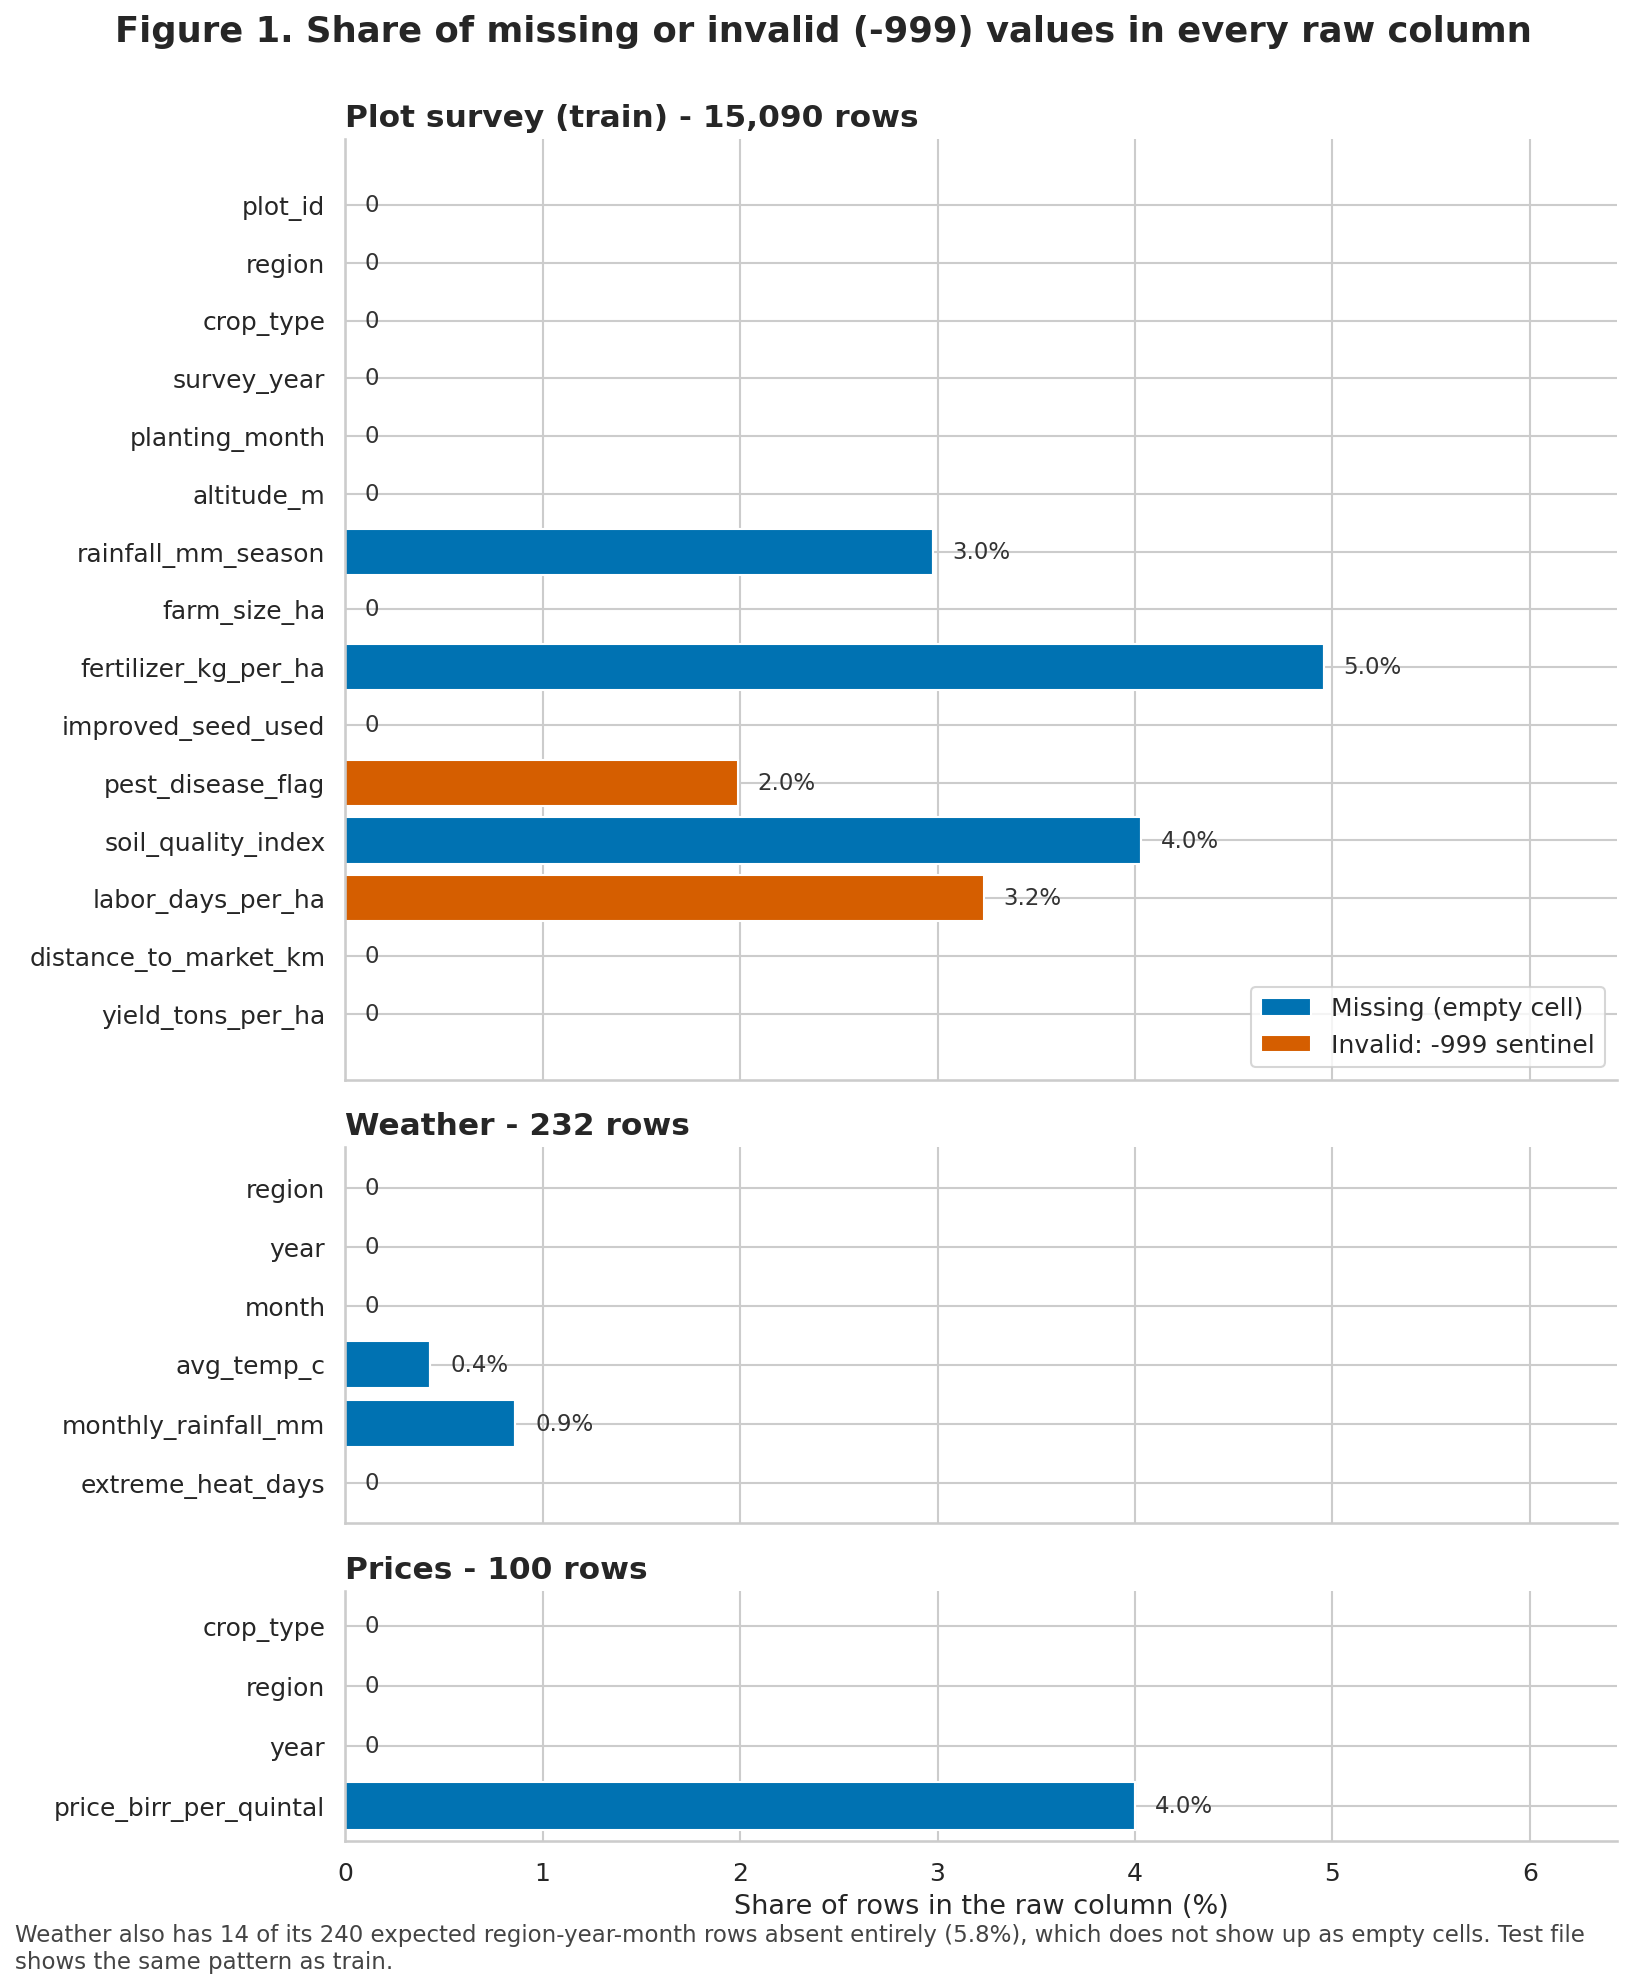

In [4]:
def missing_share(raw):
    out = []
    for col in raw.columns:
        miss = raw[col].isna().mean() * 100
        sent = (raw[col] == -999).mean() * 100 if pd.api.types.is_numeric_dtype(raw[col]) else 0.0
        out.append((col, miss, sent))
    return pd.DataFrame(out, columns=["column", "missing_pct", "sentinel_pct"])

tables = [("Plot survey (train)", train_raw), ("Weather", weather_raw), ("Prices", prices_raw)]
miss = {name: missing_share(raw) for name, raw in tables}
x_max = max((t.missing_pct + t.sentinel_pct).max() for t in miss.values()) * 1.3

fig, axes = plt.subplots(3, 1, figsize=(11, 13), gridspec_kw={"height_ratios": [len(t) for t in miss.values()]}, sharex=True)
for ax, (name, raw) in zip(axes, tables):
    t = miss[name].iloc[::-1]
    ax.barh(t.column, t.missing_pct, color="#0072B2", label="Missing (empty cell)")
    ax.barh(t.column, t.sentinel_pct, left=t.missing_pct, color="#D55E00", label="Invalid: -999 sentinel")
    for y, (a, b) in enumerate(zip(t.missing_pct, t.sentinel_pct)):
        ax.text(a + b + 0.1, y, f"{a + b:.1f}%" if a + b > 0 else "0", va="center", fontsize=11, color="#333")
    ax.set_title(f"{name} - {len(raw):,} rows", loc="left")
    ax.set_xlim(0, x_max)
    ax.set_ylabel("")
axes[0].legend(loc="lower right")
axes[-1].set_xlabel("Share of rows in the raw column (%)")
fig.suptitle("Figure 1. Share of missing or invalid (-999) values in every raw column", fontsize=17, fontweight="bold", y=0.995)
fig.text(0.01, -0.005, "Weather also has 14 of its 240 expected region-year-month rows absent entirely (5.8%), which does not show up as empty cells. Test file shows the same pattern as train.",
         fontsize=11, color="#444", wrap=True)
fig.tight_layout()
save_fig(fig, "fig01_missingness.png")
for name, t in miss.items():
    bad = t[(t.missing_pct + t.sentinel_pct) > 0]
    print(name, "->", {r.column: round(r.missing_pct + r.sentinel_pct, 1) for r in bad.itertuples()})

## Figure 2 · Before vs after cleaning

saved ../figures/fig02_before_after_cleaning.png  (2068 px wide)


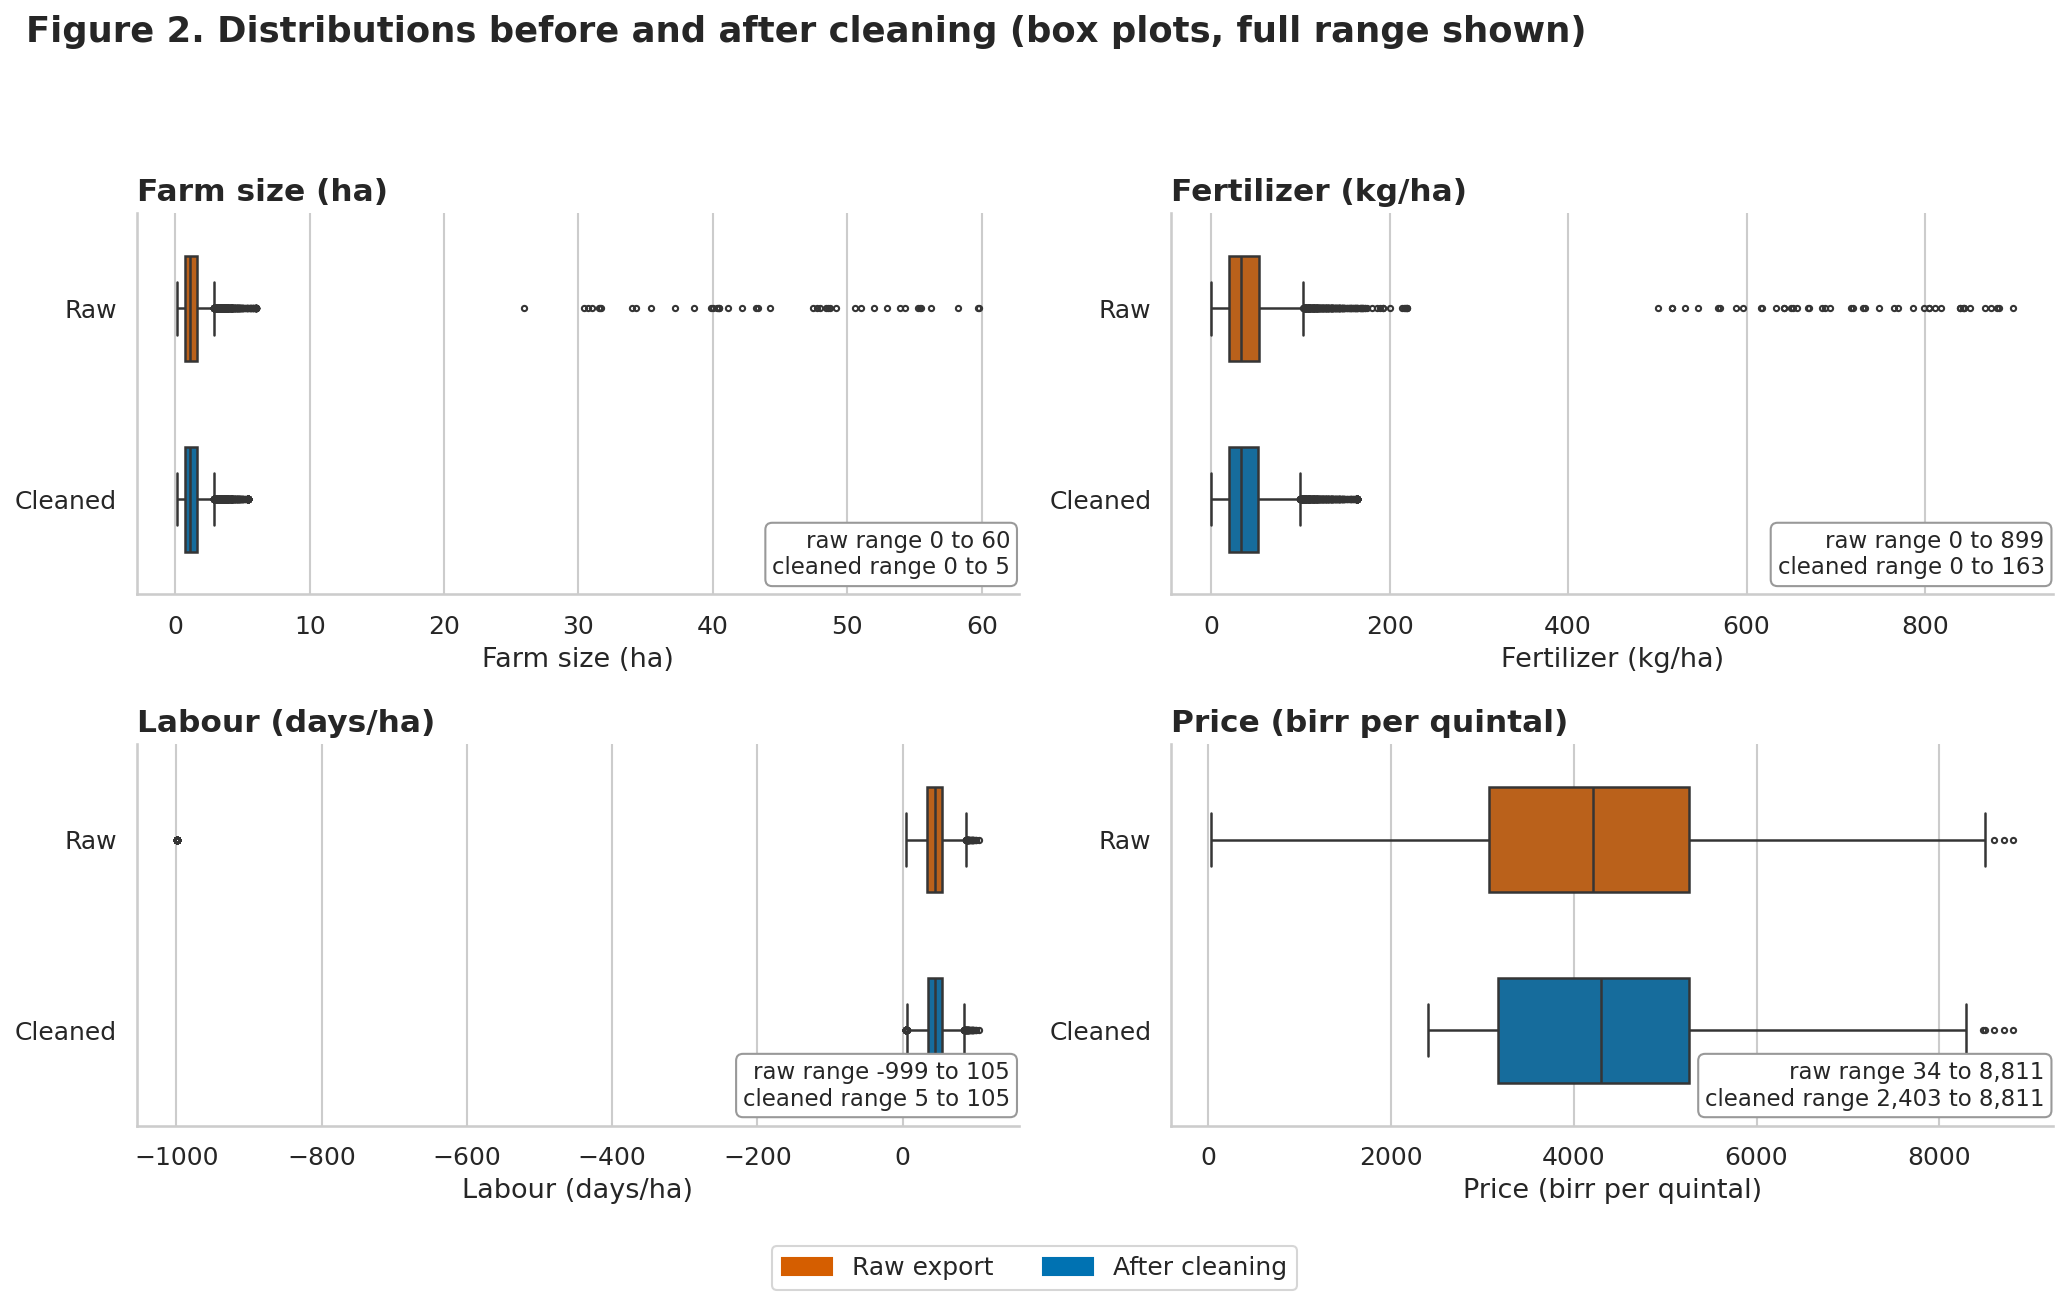

In [5]:
panels = [("Farm size (ha)", train_raw.farm_size_ha, df.farm_size_ha),
          ("Fertilizer (kg/ha)", train_raw.fertilizer_kg_per_ha, df.fertilizer_kg_per_ha),
          ("Labour (days/ha)", train_raw.labor_days_per_ha, df.labor_days_per_ha),
          ("Price (birr per quintal)", prices_raw.price_birr_per_quintal, prices_clean.price_birr_per_quintal)]
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
for ax, (title, before, after) in zip(axes.ravel(), panels):
    long = pd.concat([pd.DataFrame({"stage": "Raw", "value": before.dropna()}), pd.DataFrame({"stage": "Cleaned", "value": after.dropna()})])
    sns.boxplot(data=long, x="value", y="stage", hue="stage", order=["Raw", "Cleaned"], palette={"Raw": C_RAW, "Cleaned": C_CLEAN},
                orient="h", width=0.55, fliersize=2.5, linewidth=1.2, ax=ax, legend=False)
    ax.set_title(title, loc="left")
    ax.set_xlabel(title)
    ax.set_ylabel("")
    ax.text(0.99, 0.04, f"raw range {before.min():,.0f} to {before.max():,.0f}\ncleaned range {after.min():,.0f} to {after.max():,.0f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=11, bbox=dict(boxstyle="round", fc="white", ec="#999"))
fig.legend(handles=[Patch(color=C_RAW, label="Raw export"), Patch(color=C_CLEAN, label="After cleaning")], loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Figure 2. Distributions before and after cleaning (box plots, full range shown)", fontsize=17, fontweight="bold", x=0.02, ha="left", y=1.0)
fig.tight_layout(rect=(0, 0.04, 1, 0.95))
save_fig(fig, "fig02_before_after_cleaning.png")

## Figure 3 · Yield distribution

saved ../figures/fig03_yield_distribution.png  (2217 px wide)
           median   std    max
crop_type                     
maize        3.77  1.58  10.86
wheat        2.69  1.41   9.70
sorghum      2.51  0.97   6.47
barley       2.38  1.16   6.72
teff         2.00  0.99   5.59
skewness: 0.82 | mean 2.76 | median 2.58


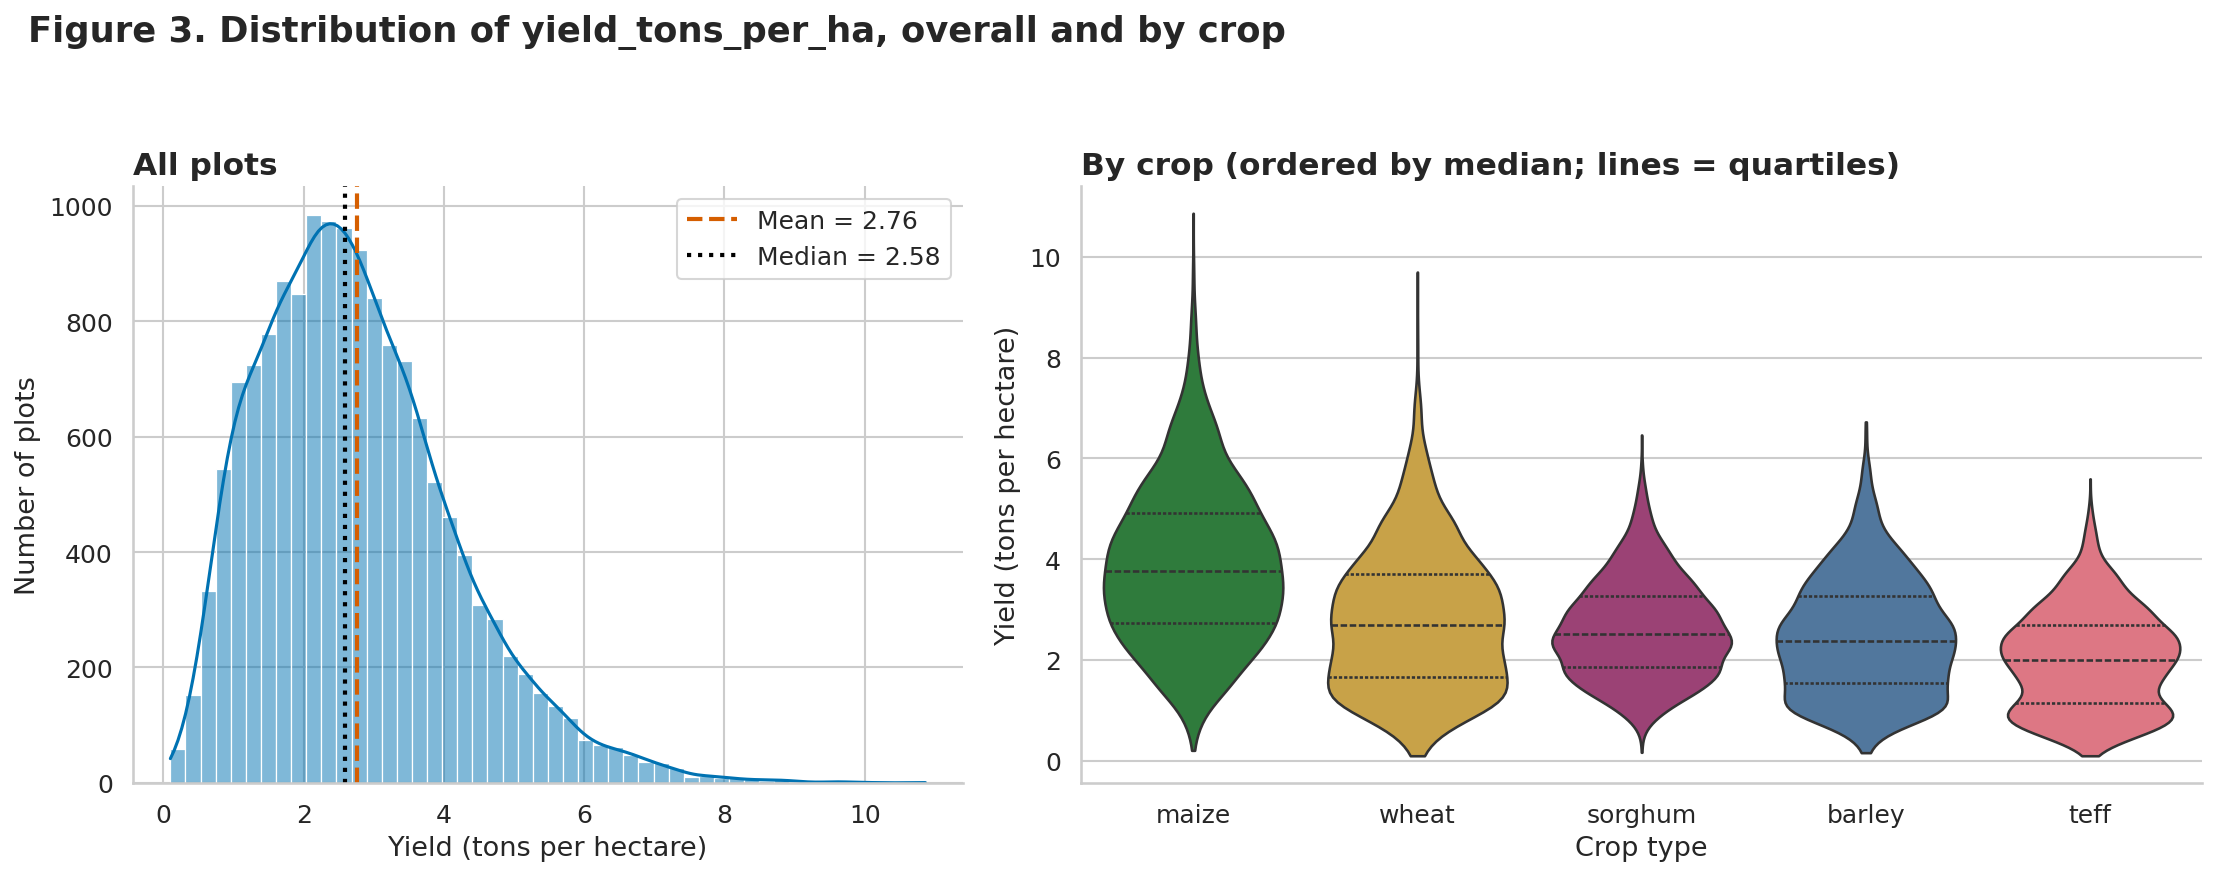

In [6]:
crop_order = df.groupby("crop_type").yield_tons_per_ha.median().sort_values(ascending=False).index.tolist()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.35]})
sns.histplot(df.yield_tons_per_ha, bins=50, kde=True, color="#0072B2", ax=ax1)
ax1.axvline(df.yield_tons_per_ha.mean(), color="#D55E00", ls="--", lw=2, label=f"Mean = {df.yield_tons_per_ha.mean():.2f}")
ax1.axvline(df.yield_tons_per_ha.median(), color="#000000", ls=":", lw=2, label=f"Median = {df.yield_tons_per_ha.median():.2f}")
ax1.set_title("All plots", loc="left"); ax1.set_xlabel("Yield (tons per hectare)"); ax1.set_ylabel("Number of plots"); ax1.legend()
sns.violinplot(data=df, x="crop_type", y="yield_tons_per_ha", hue="crop_type", order=crop_order, palette=CROP_COLORS, inner="quartile", cut=0, legend=False, ax=ax2)
ax2.set_title("By crop (ordered by median; lines = quartiles)", loc="left"); ax2.set_xlabel("Crop type"); ax2.set_ylabel("Yield (tons per hectare)")
fig.suptitle("Figure 3. Distribution of yield_tons_per_ha, overall and by crop", fontsize=17, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_fig(fig, "fig03_yield_distribution.png")
print(df.groupby("crop_type").yield_tons_per_ha.agg(["median", "std", "max"]).round(2).loc[crop_order])
print("skewness:", round(df.yield_tons_per_ha.skew(), 2), "| mean", round(df.yield_tons_per_ha.mean(), 2), "| median", round(df.yield_tons_per_ha.median(), 2))

## Figure 4 · Region × crop heatmap

saved ../figures/fig04_region_crop_heatmap.png  (1497 px wide)
best: ('SNNPR', 'maize') 4.79 | worst: ('Somali', 'teff') 0.83 | plots per cell: 533 to 645


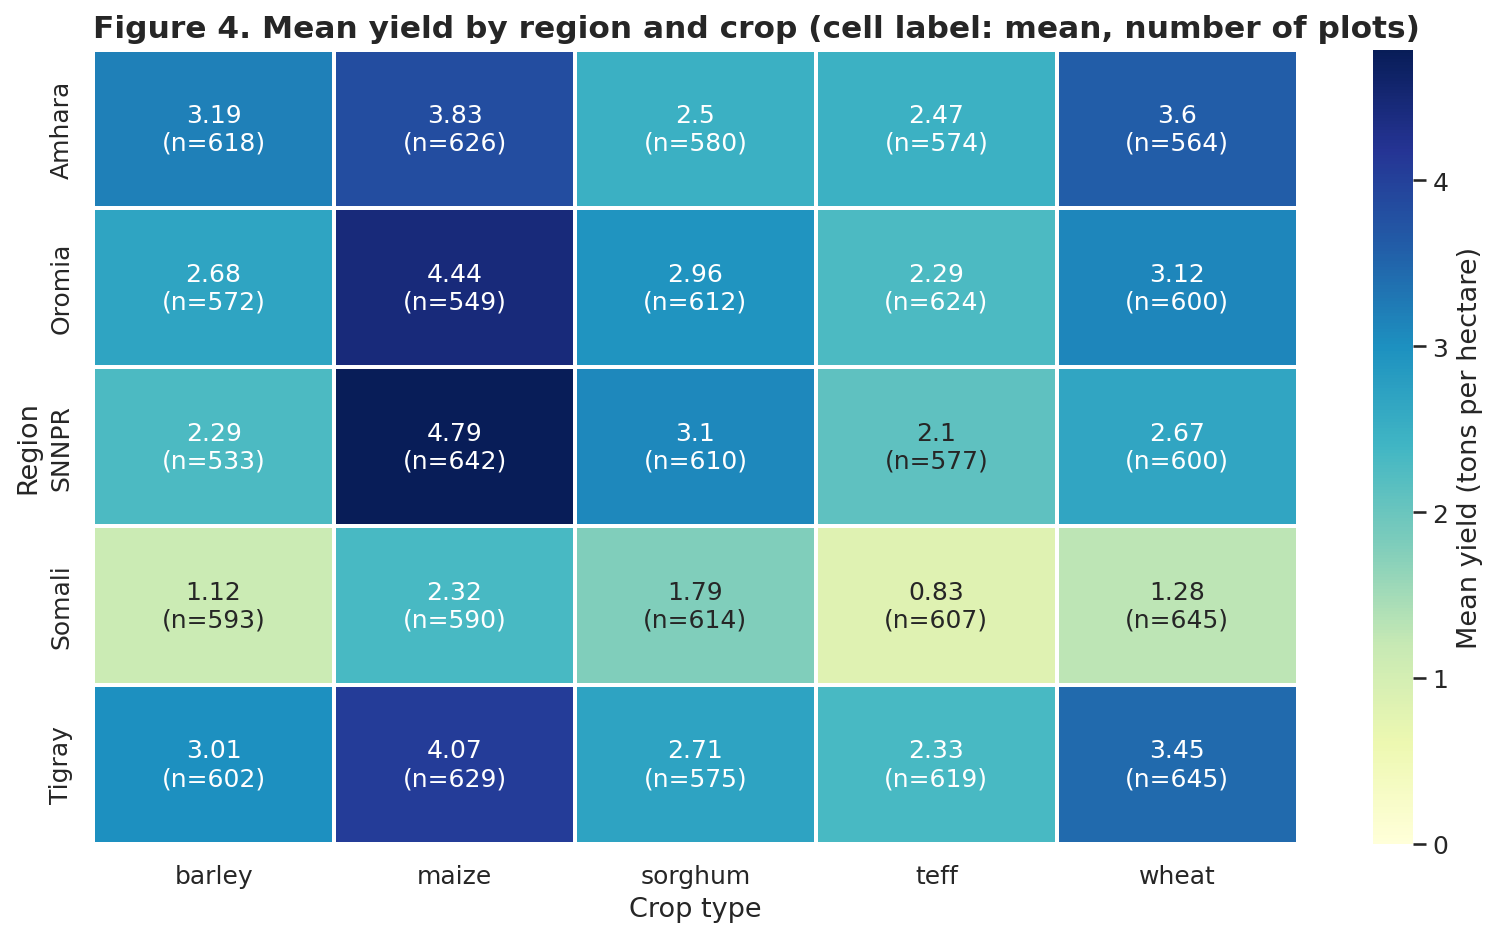

In [7]:
pivot = df.pivot_table("yield_tons_per_ha", index="region", columns="crop_type", aggfunc="mean")
counts = df.pivot_table("yield_tons_per_ha", index="region", columns="crop_type", aggfunc="count")
annot = pivot.round(2).astype(str) + "\n(n=" + counts.astype(str) + ")"
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(pivot, annot=annot, fmt="", cmap="YlGnBu", vmin=0, linewidths=1, linecolor="white", annot_kws={"fontsize": 12},
            cbar_kws={"label": "Mean yield (tons per hectare)"}, ax=ax)
ax.set_title("Figure 4. Mean yield by region and crop (cell label: mean, number of plots)", loc="left")
ax.set_xlabel("Crop type"); ax.set_ylabel("Region")
fig.tight_layout()
save_fig(fig, "fig04_region_crop_heatmap.png")
s = pivot.stack()
print("best:", s.idxmax(), round(s.max(), 2), "| worst:", s.idxmin(), round(s.min(), 2), "| plots per cell:", counts.values.min(), "to", counts.values.max())

## Figure 5 · Correlation heatmap

saved ../figures/fig05_correlation_heatmap.png  (2019 px wide)
Correlation with yield (strongest first):
season_extreme_heat_days   -0.460
season_mean_temp_c         -0.451
aridity_ratio              -0.418
season_rain_total_mm        0.300
pest_disease_flag          -0.234
fert_x_improved_seed        0.211
soil_quality_index          0.211
improved_seed_used          0.179


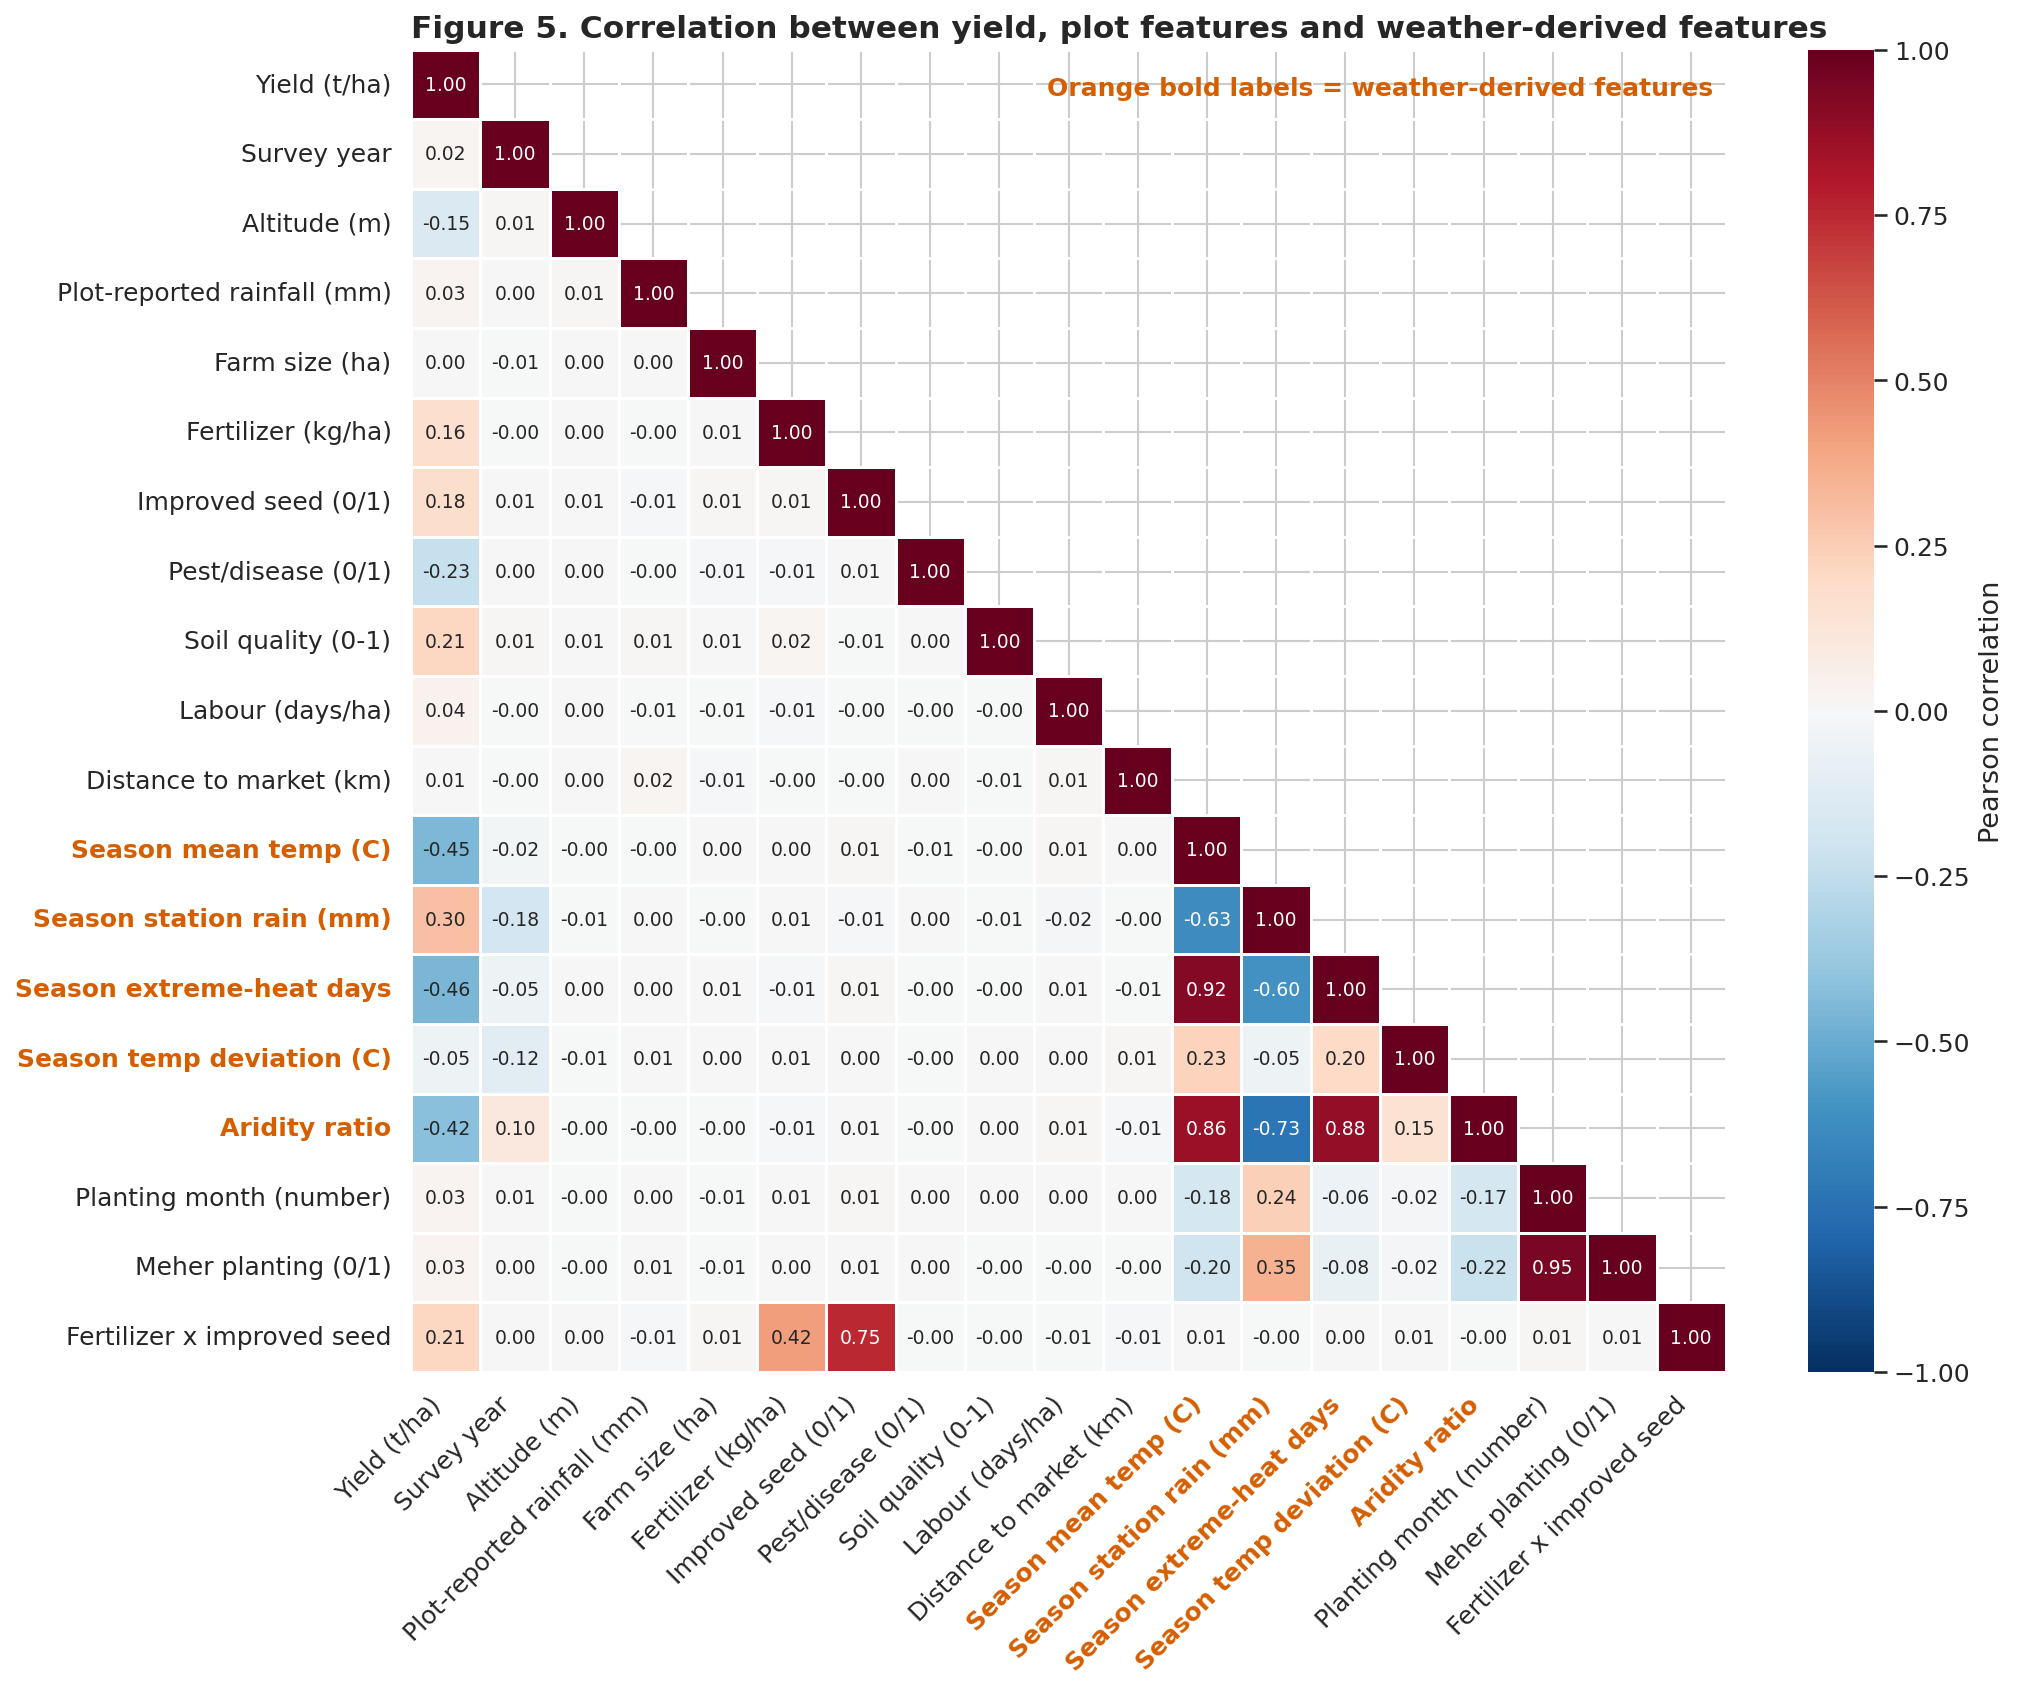

In [8]:
corr_cols = ["yield_tons_per_ha", "survey_year", "altitude_m", "rainfall_mm_season", "farm_size_ha", "fertilizer_kg_per_ha", "improved_seed_used",
             "pest_disease_flag", "soil_quality_index", "labor_days_per_ha", "distance_to_market_km",
             "season_mean_temp_c", "season_rain_total_mm", "season_extreme_heat_days", "season_temp_dev_c", "aridity_ratio",
             "planting_month_num", "is_meher_planting", "fert_x_improved_seed"]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(14, 11.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", annot_kws={"fontsize": 9}, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Pearson correlation"}, ax=ax)
labels = [NICE[c] for c in corr_cols]
ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels, rotation=0)
for lab, col in zip(ax.get_xticklabels(), corr_cols):
    if col in WEATHER_DERIVED: lab.set_color(C_WEATHER); lab.set_fontweight("bold")
for lab, col in zip(ax.get_yticklabels(), corr_cols):
    if col in WEATHER_DERIVED: lab.set_color(C_WEATHER); lab.set_fontweight("bold")
ax.set_title("Figure 5. Correlation between yield, plot features and weather-derived features", loc="left")
ax.text(0.99, 0.98, "Orange bold labels = weather-derived features", transform=ax.transAxes, ha="right", va="top", color=C_WEATHER, fontsize=12, fontweight="bold")
fig.tight_layout()
save_fig(fig, "fig05_correlation_heatmap.png")
print("Correlation with yield (strongest first):")
print(corr["yield_tons_per_ha"].drop("yield_tons_per_ha").sort_values(key=abs, ascending=False).round(3).head(8).to_string())

## Figure 6 · Monthly climate by region with growing-season windows

saved ../figures/fig06_climate_by_region.png  (1824 px wide)
        mean_temp  mean_monthly_rain
region                              
Amhara       17.1               84.5
Oromia       19.1               87.8
SNNPR        20.5              103.4
Somali       28.7               30.0
Tigray       18.0               75.6

Wettest month:
region month  monthly_rainfall_mm
Amhara   Aug                183.0
Oromia   Aug                192.0
 SNNPR   Jun                217.0
Somali   Jul                 62.0
Tigray   Jun                141.0


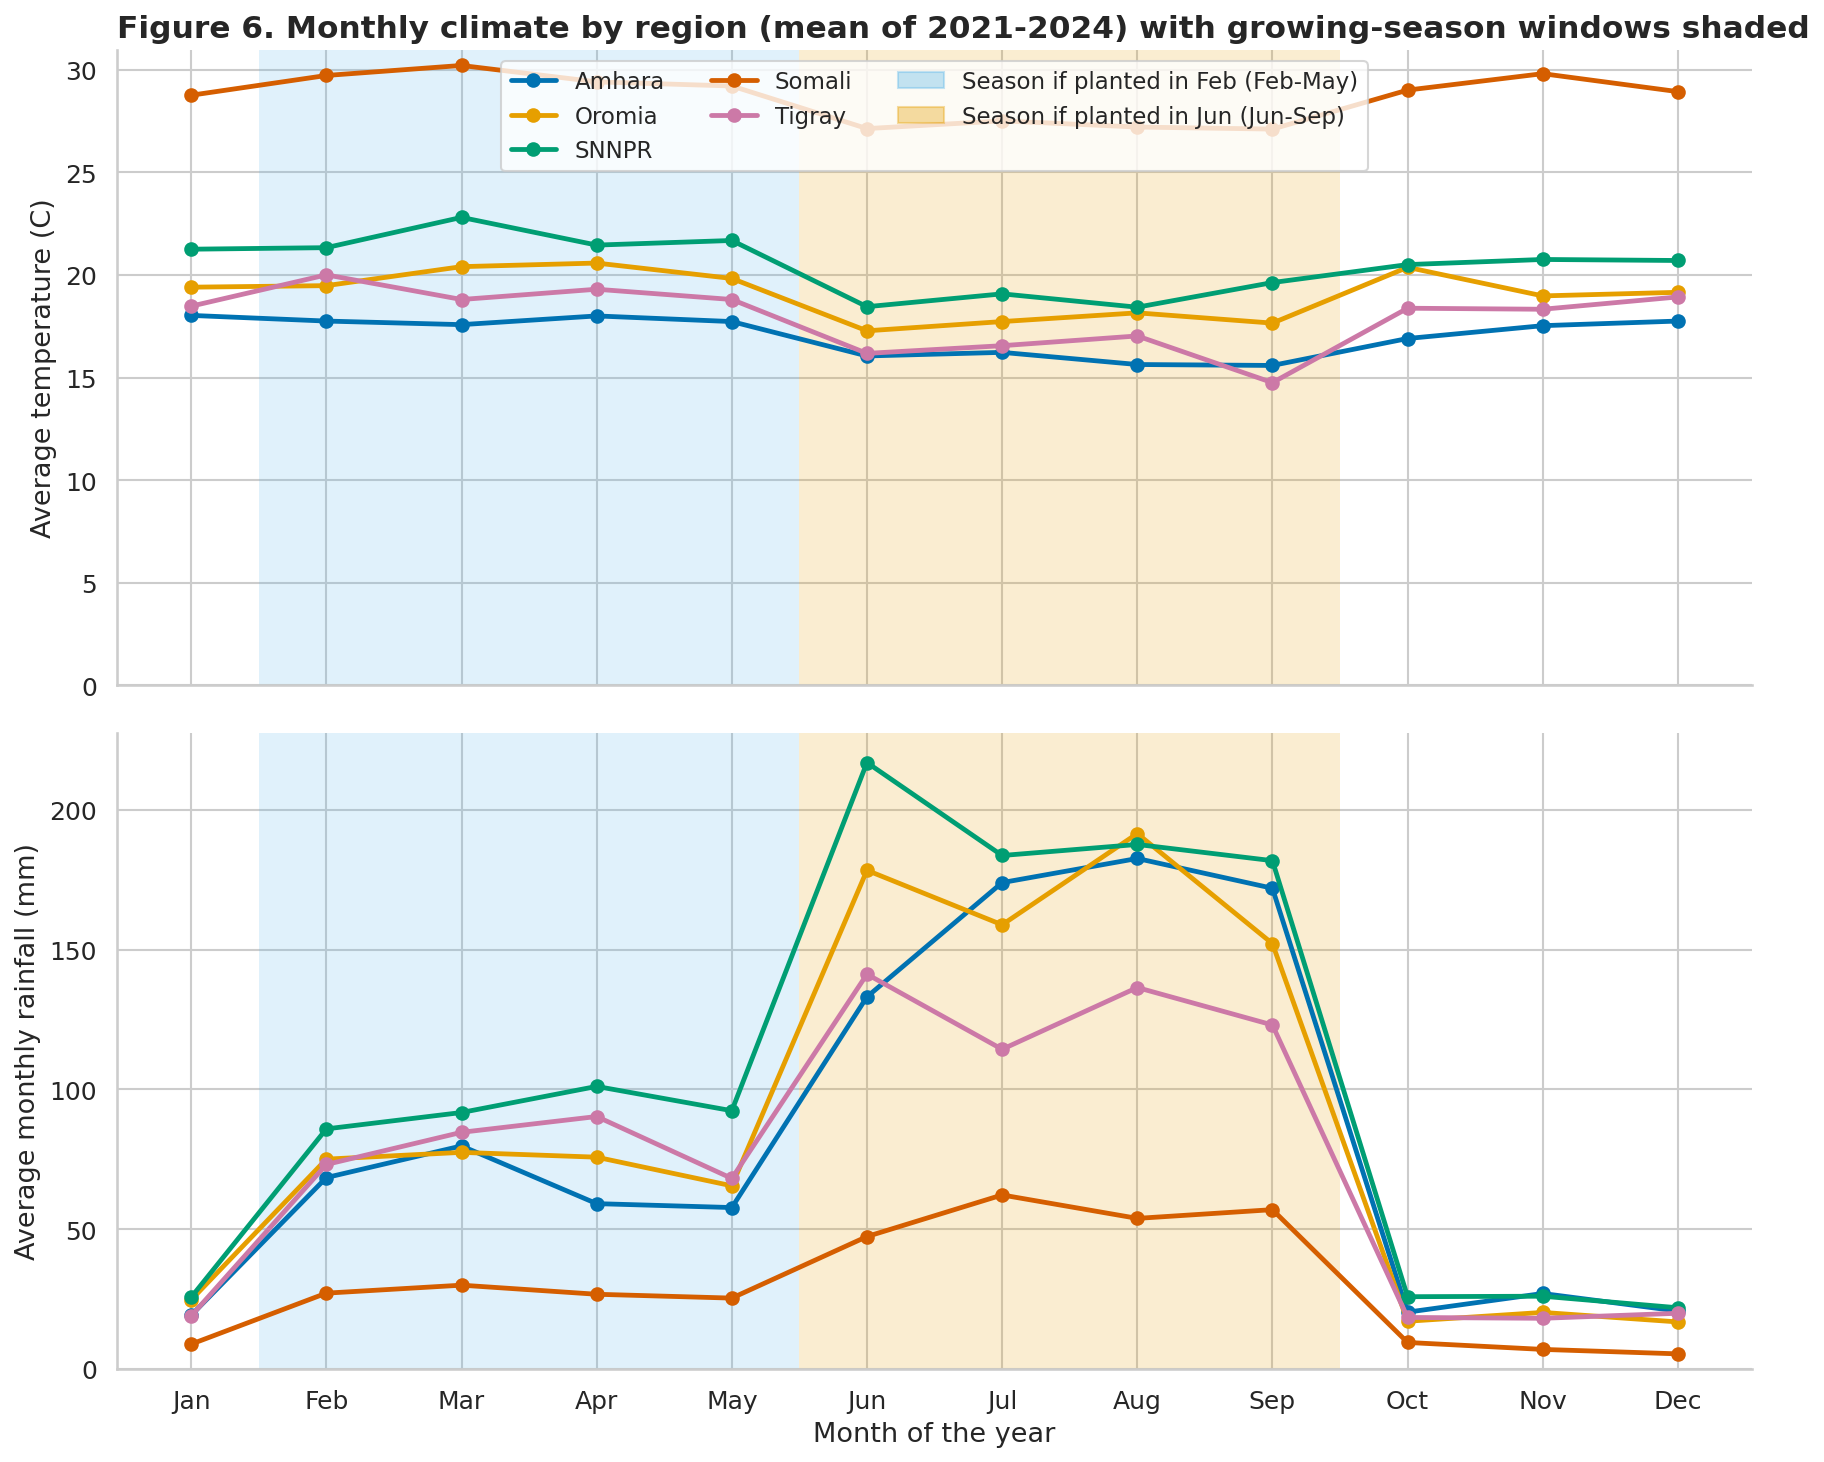

In [9]:
climate = weather_clean.groupby(["region", "month_num"])[["avg_temp_c", "monthly_rainfall_mm"]].mean().reset_index()
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
for ax, col, ylab in zip(axes, ["avg_temp_c", "monthly_rainfall_mm"], ["Average temperature (C)", "Average monthly rainfall (mm)"]):
    ax.axvspan(1.5, 5.5, color="#56B4E9", alpha=0.18, lw=0)      # Feb planting: Feb-May
    ax.axvspan(5.5, 9.5, color="#E69F00", alpha=0.18, lw=0)      # Jun planting: Jun-Sep
    for region in REGIONS:
        d = climate[climate.region == region]
        ax.plot(d.month_num, d[col], marker="o", lw=2.3, color=REGION_COLORS[region], label=region)
    ax.set_ylabel(ylab)
    ax.set_ylim(0, None)
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(MONTHS); axes[1].set_xlabel("Month of the year")
axes[0].set_title("Figure 6. Monthly climate by region (mean of 2021-2024) with growing-season windows shaded", loc="left")
handles = [Line2D([0], [0], color=REGION_COLORS[r], marker="o", lw=2.3, label=r) for r in REGIONS]
handles += [Patch(color="#56B4E9", alpha=0.35, label="Season if planted in Feb (Feb-May)"), Patch(color="#E69F00", alpha=0.35, label="Season if planted in Jun (Jun-Sep)")]
axes[0].legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.0), fontsize=11)
fig.tight_layout()
save_fig(fig, "fig06_climate_by_region.png")
print(climate.groupby("region").agg(mean_temp=("avg_temp_c", "mean"), mean_monthly_rain=("monthly_rainfall_mm", "mean")).round(1))
wet = climate.loc[climate.groupby("region").monthly_rainfall_mm.idxmax()][["region", "month_num", "monthly_rainfall_mm"]]
wet["month"] = wet.month_num.map(lambda m: MONTHS[m - 1]); print("\nWettest month:"); print(wet[["region", "month", "monthly_rainfall_mm"]].round(0).to_string(index=False))

## Figure 7 · Yield vs growing-season temperature, per crop

saved ../figures/fig07_yield_vs_season_temp.png  (2516 px wide)
barley   best bin ~16.1 C -> 3.47 t/ha | coolest bin 3.31 | hottest bin 1.13 | temp range 15.4-30.1
maize    best bin ~21.0 C -> 5.06 t/ha | coolest bin 3.45 | hottest bin 1.90 | temp range 15.5-30.0
sorghum  best bin ~20.0 C -> 3.33 t/ha | coolest bin 2.27 | hottest bin 1.52 | temp range 15.6-30.0
teff     best bin ~17.6 C -> 2.50 t/ha | coolest bin 2.48 | hottest bin 0.78 | temp range 15.6-30.2
wheat    best bin ~16.1 C -> 3.93 t/ha | coolest bin 3.89 | hottest bin 1.27 | temp range 15.4-30.0


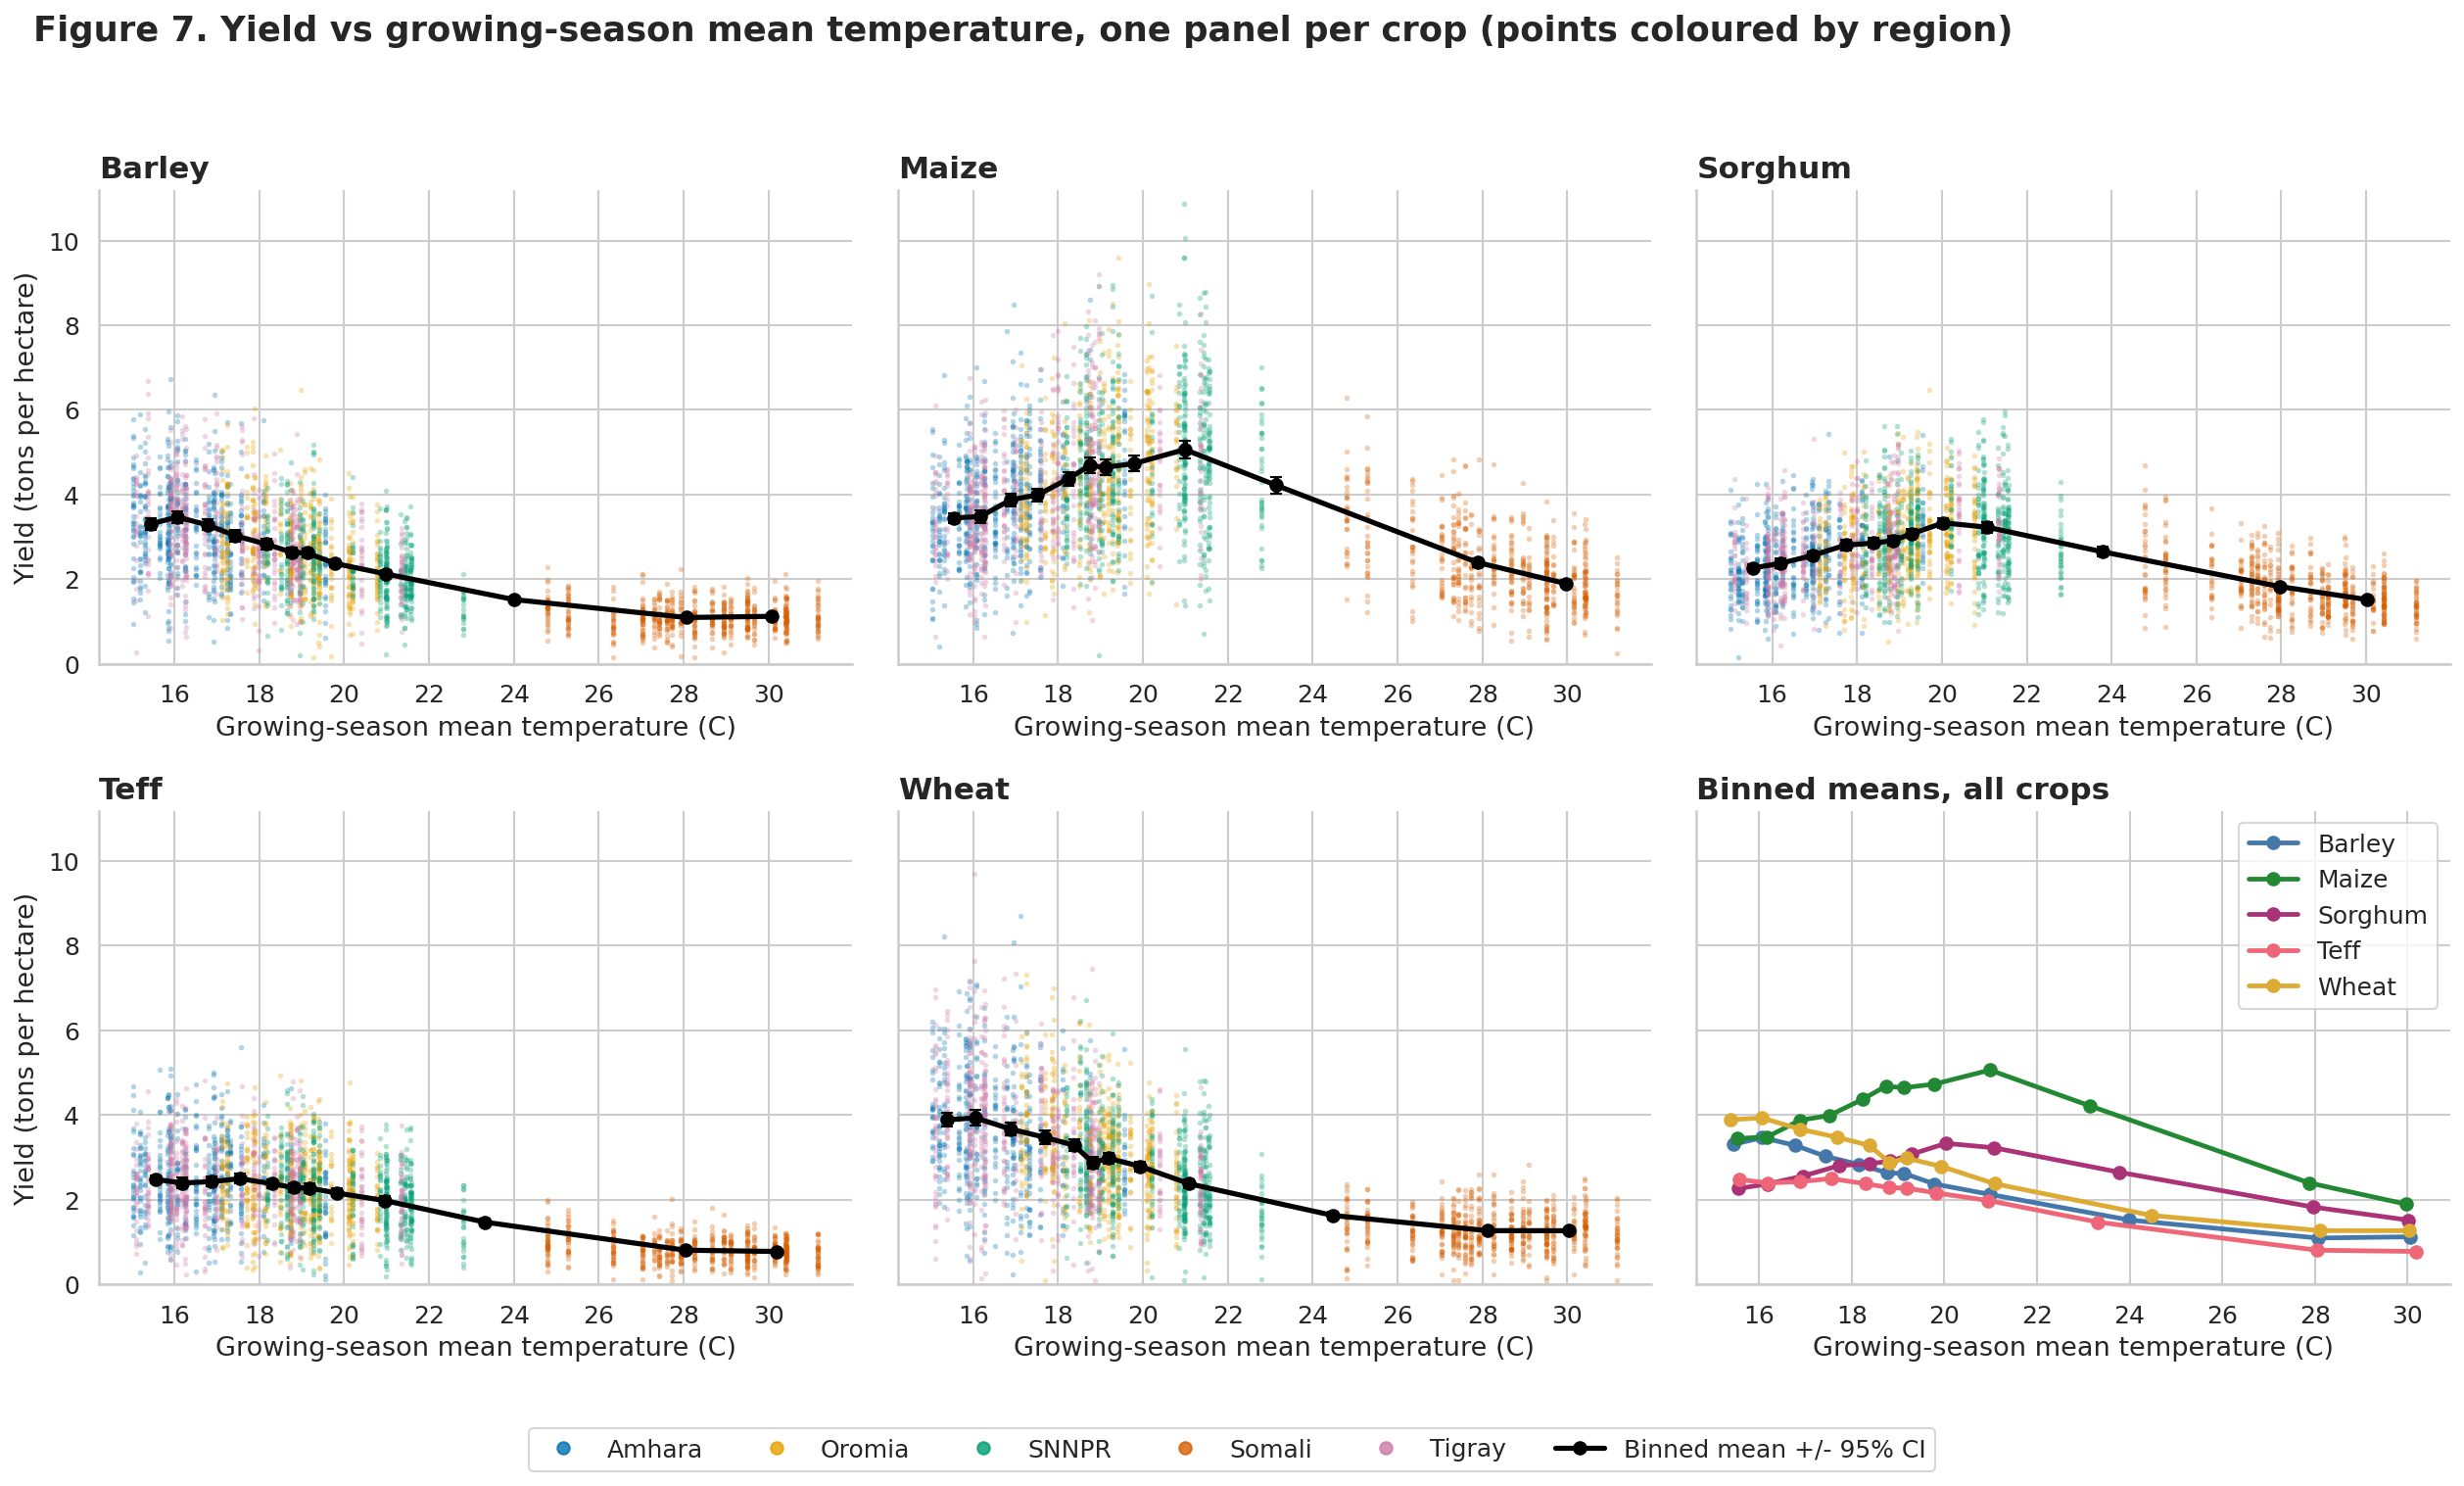

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharey=True)
binned_all = {}
for ax, crop in zip(axes.ravel(), CROPS):
    d = df[df.crop_type == crop]
    for region in REGIONS:
        r = d[d.region == region]
        ax.scatter(r.season_mean_temp_c, r.yield_tons_per_ha, s=7, alpha=0.30, color=REGION_COLORS[region], linewidths=0)
    bins = pd.qcut(d.season_mean_temp_c, 12, duplicates="drop")
    b = d.groupby(bins, observed=True).agg(temp=("season_mean_temp_c", "mean"), mean_yield=("yield_tons_per_ha", "mean"),
                                           se=("yield_tons_per_ha", lambda s: s.std() / np.sqrt(len(s))))
    binned_all[crop] = b
    ax.errorbar(b.temp, b.mean_yield, yerr=1.96 * b.se, color="black", marker="o", ms=6, lw=2.5, capsize=3)
    ax.set_title(crop.capitalize(), loc="left"); ax.set_xlabel("Growing-season mean temperature (C)")
for ax in axes[:, 0]: ax.set_ylabel("Yield (tons per hectare)")
axes[0, 0].set_ylim(0, df.yield_tons_per_ha.max() * 1.03)     # shared axis: show every plot, nothing cropped

ax = axes[1, 2]
for crop in CROPS:
    b = binned_all[crop]; ax.plot(b.temp, b.mean_yield, marker="o", lw=2.3, color=CROP_COLORS[crop], label=crop.capitalize())
ax.set_title("Binned means, all crops", loc="left"); ax.set_xlabel("Growing-season mean temperature (C)"); ax.legend(loc="upper right")
handles = [Line2D([0], [0], marker="o", ls="", color=REGION_COLORS[r], label=r, alpha=0.8) for r in REGIONS]
handles.append(Line2D([0], [0], color="black", marker="o", lw=2.5, label="Binned mean +/- 95% CI"))
fig.legend(handles=handles, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.02), fontsize=12)
fig.suptitle("Figure 7. Yield vs growing-season mean temperature, one panel per crop (points coloured by region)", fontsize=17, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0.04, 1, 0.95))
save_fig(fig, "fig07_yield_vs_season_temp.png")
for crop in CROPS:
    b = binned_all[crop]; top = b.mean_yield.idxmax()
    print(f"{crop:8s} best bin ~{b.temp[top]:.1f} C -> {b.mean_yield.max():.2f} t/ha | coolest bin {b.mean_yield.iloc[0]:.2f} | hottest bin {b.mean_yield.iloc[-1]:.2f} | temp range {b.temp.min():.1f}-{b.temp.max():.1f}")

## Figure 8 · Price trends

saved ../figures/fig08_price_trends.png  (2181 px wide)
crop_type
sorghum    29.9
wheat      29.1
barley     24.6
maize      24.2
teff       20.8


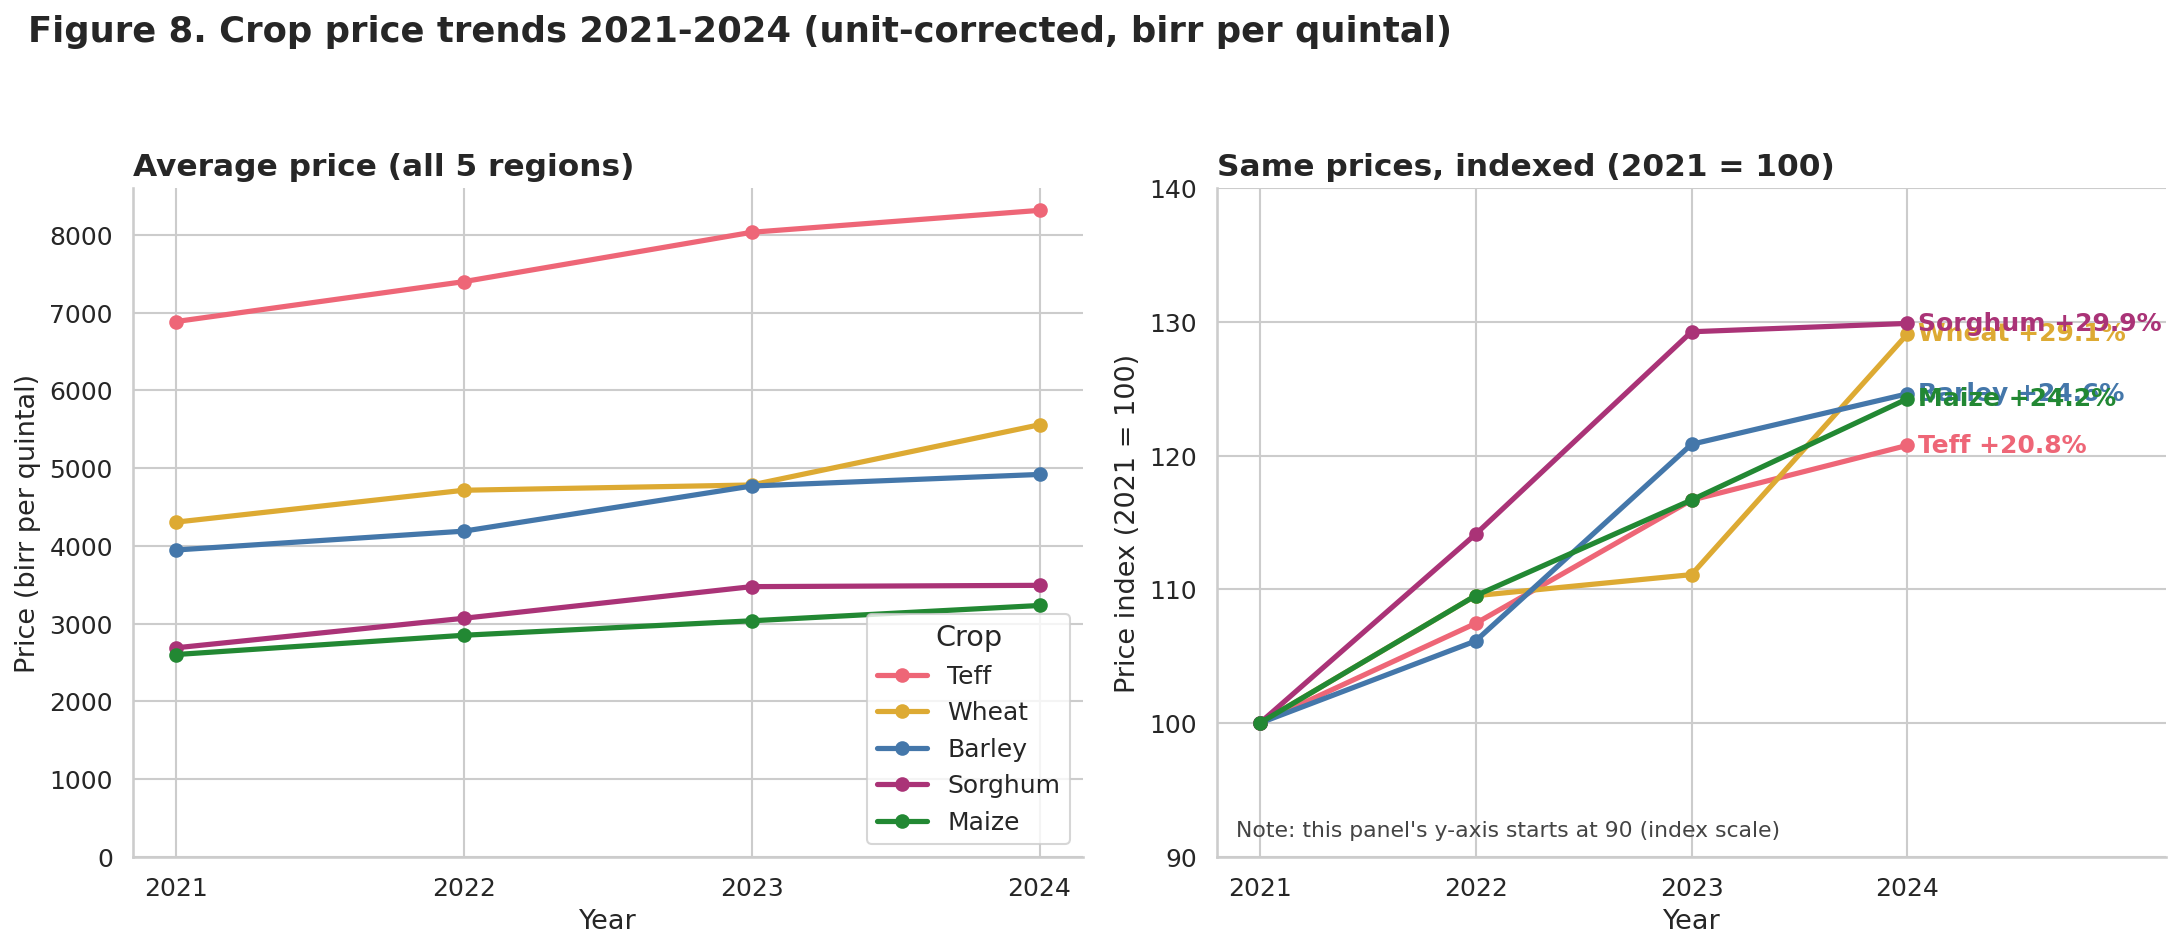

In [11]:
price_year = prices_clean.groupby(["crop_type", "year"]).price_birr_per_quintal.mean().unstack()
index_100 = price_year.div(price_year[2021], axis=0) * 100
order = price_year[2024].sort_values(ascending=False).index.tolist()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
for crop in order:
    ax1.plot(price_year.columns, price_year.loc[crop], marker="o", lw=2.5, color=CROP_COLORS[crop], label=crop.capitalize())
    ax2.plot(index_100.columns, index_100.loc[crop], marker="o", lw=2.5, color=CROP_COLORS[crop])
    ax2.text(2024.05, index_100.loc[crop, 2024], f"{crop.capitalize()} +{index_100.loc[crop, 2024] - 100:.1f}%", color=CROP_COLORS[crop], va="center", fontsize=12, fontweight="bold")
ax1.set_title("Average price (all 5 regions)", loc="left"); ax1.set_ylabel("Price (birr per quintal)"); ax1.set_ylim(0, None); ax1.legend(title="Crop")
ax2.set_title("Same prices, indexed (2021 = 100)", loc="left"); ax2.set_ylabel("Price index (2021 = 100)"); ax2.set_ylim(90, 140); ax2.set_xlim(2020.8, 2025.2)
for ax in (ax1, ax2):
    ax.set_xticks([2021, 2022, 2023, 2024]); ax.set_xlabel("Year")
ax2.text(0.02, 0.03, "Note: this panel's y-axis starts at 90 (index scale)", transform=ax2.transAxes, fontsize=10.5, color="#444")
fig.suptitle("Figure 8. Crop price trends 2021-2024 (unit-corrected, birr per quintal)", fontsize=17, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_fig(fig, "fig08_price_trends.png")
print(((price_year[2024] / price_year[2021] - 1) * 100).round(1).sort_values(ascending=False).to_string())

## Figure 9 · Revenue per hectare by crop and region

saved ../figures/fig09_revenue_by_crop_region.png  (2066 px wide)
region     Amhara  Oromia  SNNPR  Somali  Tigray
crop_type                                       
teff        174.7   176.0  168.4    65.3   175.7
wheat       175.8   144.5  138.8    61.4   162.7
maize       107.6   129.8  140.0    68.2   124.0
barley      141.7   118.7  103.0    50.8   133.2
sorghum      78.3    93.6   99.3    56.4    88.9

Crop average (birr/ha): {'teff': 151827.0, 'wheat': 135438.0, 'maize': 114192.0, 'barley': 109895.0, 'sorghum': 83278.0}


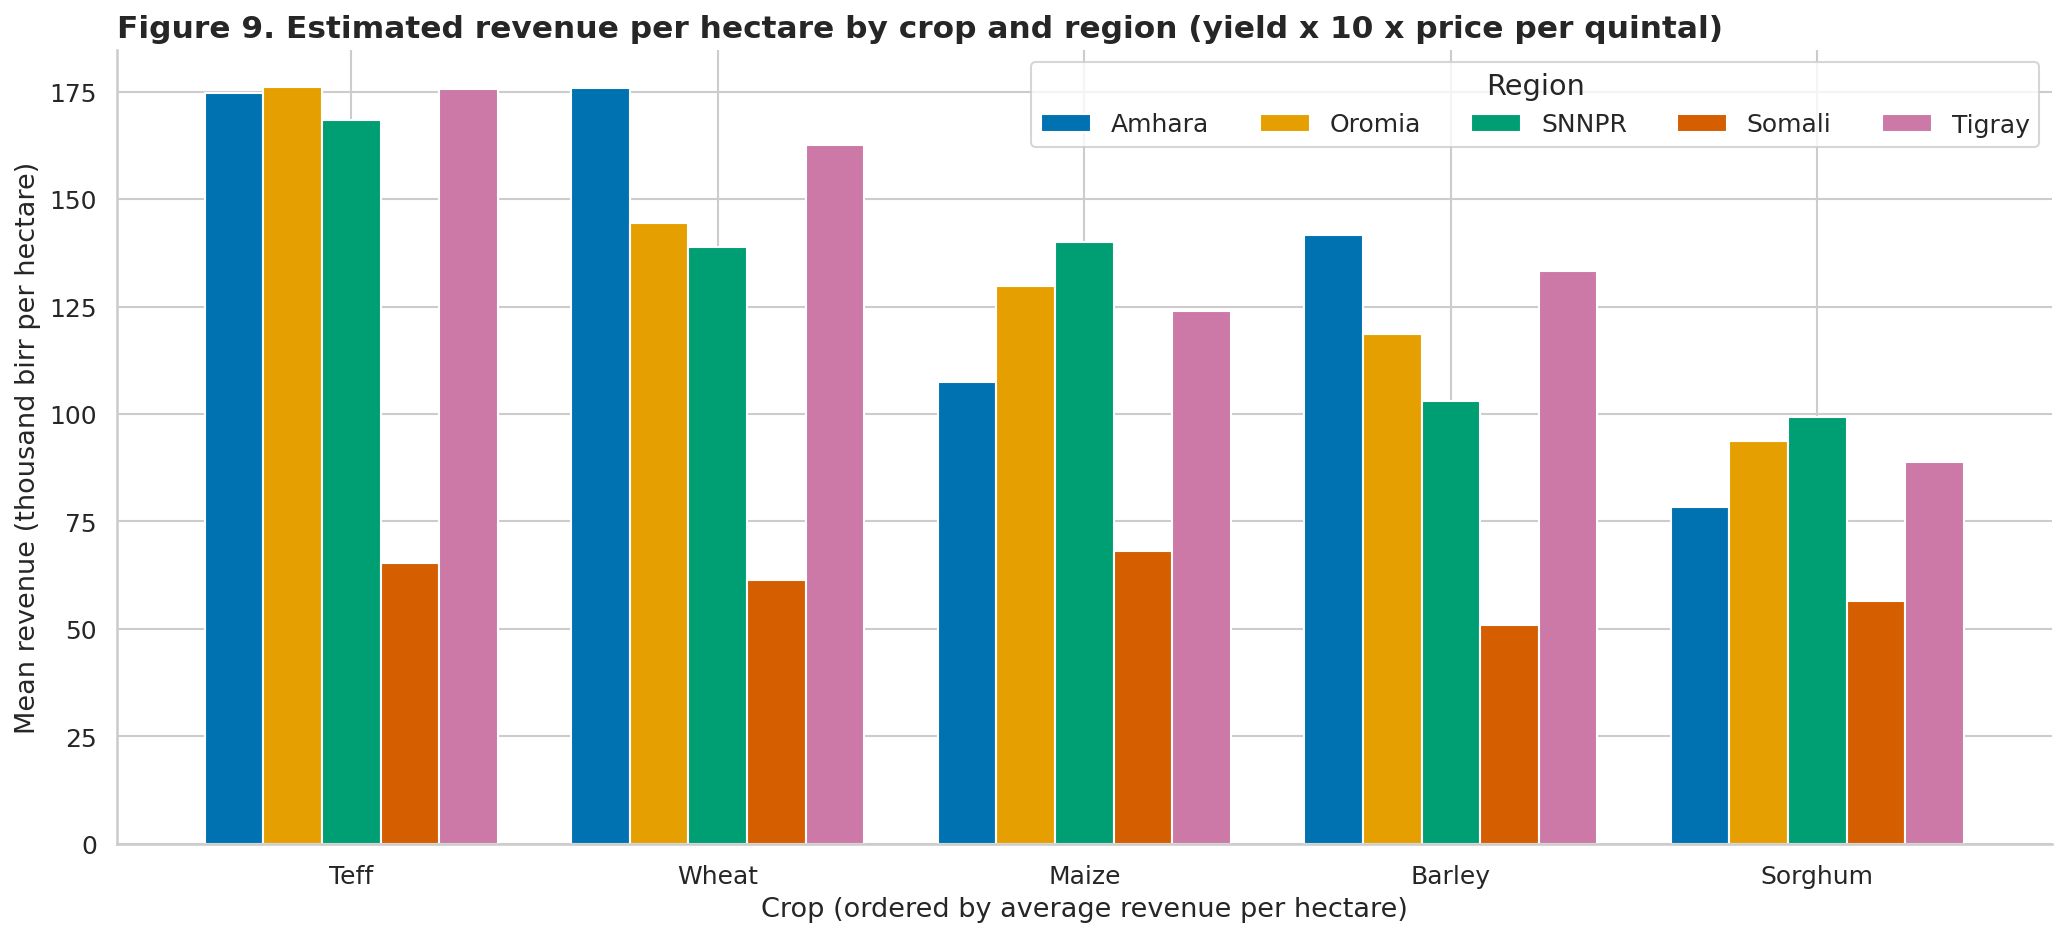

In [12]:
rev = df.groupby(["crop_type", "region"]).revenue_birr_per_ha.mean().unstack() / 1000
crop_rev_order = (df.groupby("crop_type").revenue_birr_per_ha.mean().sort_values(ascending=False)).index.tolist()
rev = rev.loc[crop_rev_order, REGIONS]
fig, ax = plt.subplots(figsize=(14, 6.5))
width = 0.16
for i, region in enumerate(REGIONS):
    ax.bar(np.arange(len(rev)) + (i - 2) * width, rev[region], width=width, color=REGION_COLORS[region], label=region)
ax.set_xticks(range(len(rev))); ax.set_xticklabels([c.capitalize() for c in rev.index])
ax.set_ylabel("Mean revenue (thousand birr per hectare)"); ax.set_xlabel("Crop (ordered by average revenue per hectare)"); ax.set_ylim(0, None)
ax.legend(title="Region", ncol=5, loc="upper right")
ax.set_title("Figure 9. Estimated revenue per hectare by crop and region (yield x 10 x price per quintal)", loc="left")
fig.tight_layout()
save_fig(fig, "fig09_revenue_by_crop_region.png")
print(rev.round(1).to_string())
print("\nCrop average (birr/ha):", (df.groupby("crop_type").revenue_birr_per_ha.mean().round(0)).sort_values(ascending=False).to_dict())

## Quick models for Figures 10-12
Train-file only. Features = all model features from notebook 01 (price is **not** used). Split: 80% train / 20% validation, `random_state=42`; 5-fold CV on the 80% part.

In [13]:
CAT_FEATURES = ["region", "crop_type"]
NUM_FEATURES = ["survey_year", "altitude_m", "rainfall_mm_season", "farm_size_ha", "fertilizer_kg_per_ha", "improved_seed_used", "pest_disease_flag",
                "soil_quality_index", "labor_days_per_ha", "distance_to_market_km", "season_mean_temp_c", "season_rain_total_mm",
                "season_extreme_heat_days", "season_temp_dev_c", "planting_month_num", "is_meher_planting", "fert_x_improved_seed", "aridity_ratio"]
assert "price_birr_per_quintal" not in CAT_FEATURES + NUM_FEATURES        # price is never a model input

X, y = df[CAT_FEATURES + NUM_FEATURES], df["yield_tons_per_ha"]
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)

def make_pipeline(model, scale=False):
    num = StandardScaler() if scale else "passthrough"
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES), ("num", num, NUM_FEATURES)])
    return Pipeline([("pre", pre), ("model", model)])

models = {
    "Mean predictor (baseline)": make_pipeline(DummyRegressor(strategy="mean")),
    "Ridge (linear)": make_pipeline(Ridge(alpha=1.0), scale=True),
    "Random forest": make_pipeline(RandomForestRegressor(n_estimators=150, min_samples_leaf=3, random_state=42, n_jobs=-1)),
    "Gradient boosting (HistGB)": make_pipeline(HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42)),
}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

rows, fitted = [], {}
for name, pipe in models.items():
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_va)
    cv = -cross_val_score(pipe, X_tr, y_tr, cv=kfold, scoring="neg_root_mean_squared_error")
    fitted[name] = pipe
    rows.append({"model": name, "val_rmse": mean_squared_error(y_va, pred) ** 0.5, "val_r2": r2_score(y_va, pred), "cv_rmse_mean": cv.mean(), "cv_rmse_std": cv.std()})
    print(f"{name:28s} val RMSE {rows[-1]['val_rmse']:.3f} | R2 {rows[-1]['val_r2']:.3f} | CV RMSE {cv.mean():.3f} +/- {cv.std():.3f}")

results = pd.DataFrame(rows)
results.to_csv("../reports/C_quick_model_results.csv", index=False)
best_name = results[~results.model.str.startswith("Mean")].sort_values("val_rmse").model.iloc[0]
best_pipe = fitted[best_name]
print("\nBest model on the validation split:", best_name)

Mean predictor (baseline)    val RMSE 1.401 | R2 -0.000 | CV RMSE 1.397 +/- 0.012
Ridge (linear)               val RMSE 0.886 | R2 0.600 | CV RMSE 0.895 +/- 0.017
Random forest                val RMSE 0.536 | R2 0.853 | CV RMSE 0.544 +/- 0.006
Gradient boosting (HistGB)   val RMSE 0.490 | R2 0.878 | CV RMSE 0.479 +/- 0.006

Best model on the validation split: Gradient boosting (HistGB)


## Figure 10 · Model comparison

saved ../figures/fig10_model_comparison.png  (1769 px wide)
                     model  val_rmse  val_r2  cv_rmse_mean  cv_rmse_std
 Mean predictor (baseline)     1.401  -0.000         1.397        0.012
            Ridge (linear)     0.886   0.600         0.895        0.017
             Random forest     0.536   0.853         0.544        0.006
Gradient boosting (HistGB)     0.490   0.878         0.479        0.006


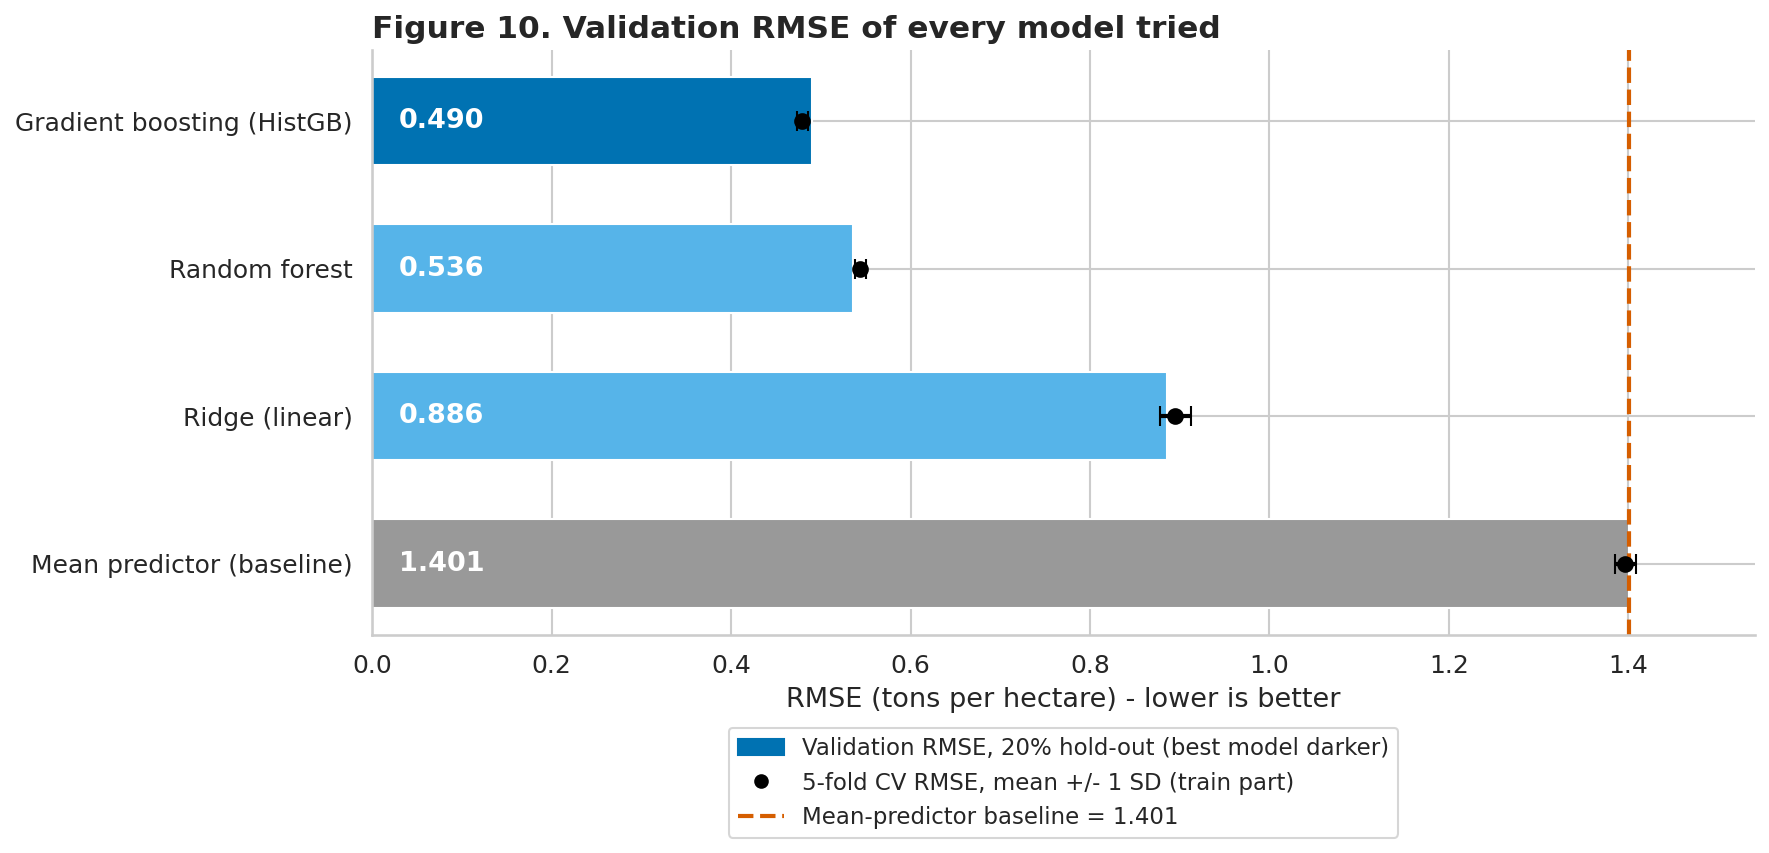

In [14]:
res = results.sort_values("val_rmse", ascending=False).reset_index(drop=True)
baseline_rmse = results.loc[results.model.str.startswith("Mean"), "val_rmse"].iloc[0]
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#999999" if m.startswith("Mean") else ("#0072B2" if m == best_name else "#56B4E9") for m in res.model]
ax.barh(res.model, res.val_rmse, color=colors, height=0.6)
ax.errorbar(res.cv_rmse_mean, res.model, xerr=res.cv_rmse_std, fmt="o", color="black", capsize=5, ms=7, lw=2)
ax.axvline(baseline_rmse, color="#D55E00", ls="--", lw=2)
for y_pos, v in enumerate(res.val_rmse):
    ax.text(0.03, y_pos, f"{v:.3f}", va="center", ha="left", color="white", fontsize=13, fontweight="bold")
ax.set_xlim(0, baseline_rmse * 1.1)
ax.set_xlabel("RMSE (tons per hectare) - lower is better"); ax.set_ylabel("")
ax.legend(handles=[Patch(color="#0072B2", label=f"Validation RMSE, 20% hold-out (best model darker)"),
                   Line2D([0], [0], marker="o", color="black", lw=2, ls="", label="5-fold CV RMSE, mean +/- 1 SD (train part)"),
                   Line2D([0], [0], color="#D55E00", ls="--", lw=2, label=f"Mean-predictor baseline = {baseline_rmse:.3f}")], loc="upper center", bbox_to_anchor=(0.5, -0.14), fontsize=11)
ax.set_title("Figure 10. Validation RMSE of every model tried", loc="left")
fig.tight_layout()
save_fig(fig, "fig10_model_comparison.png")
print(results.round(3).to_string(index=False))

## Figure 11 · Predicted vs actual, and residuals

saved ../figures/fig11_predicted_vs_actual_residuals.png  (2203 px wide)
RMSE 0.490 | MAE 0.353 | R2 0.878 | mean residual -0.010
Residual spread by predicted-yield decile (SD): [0.25, 0.37, 0.34, 0.36, 0.4, 0.48, 0.49, 0.55, 0.62, 0.81]
Residual deciles mean: [-0.01, -0.02, -0.06, -0.03, -0.04, -0.01, 0.04, -0.03, 0.02, 0.03]


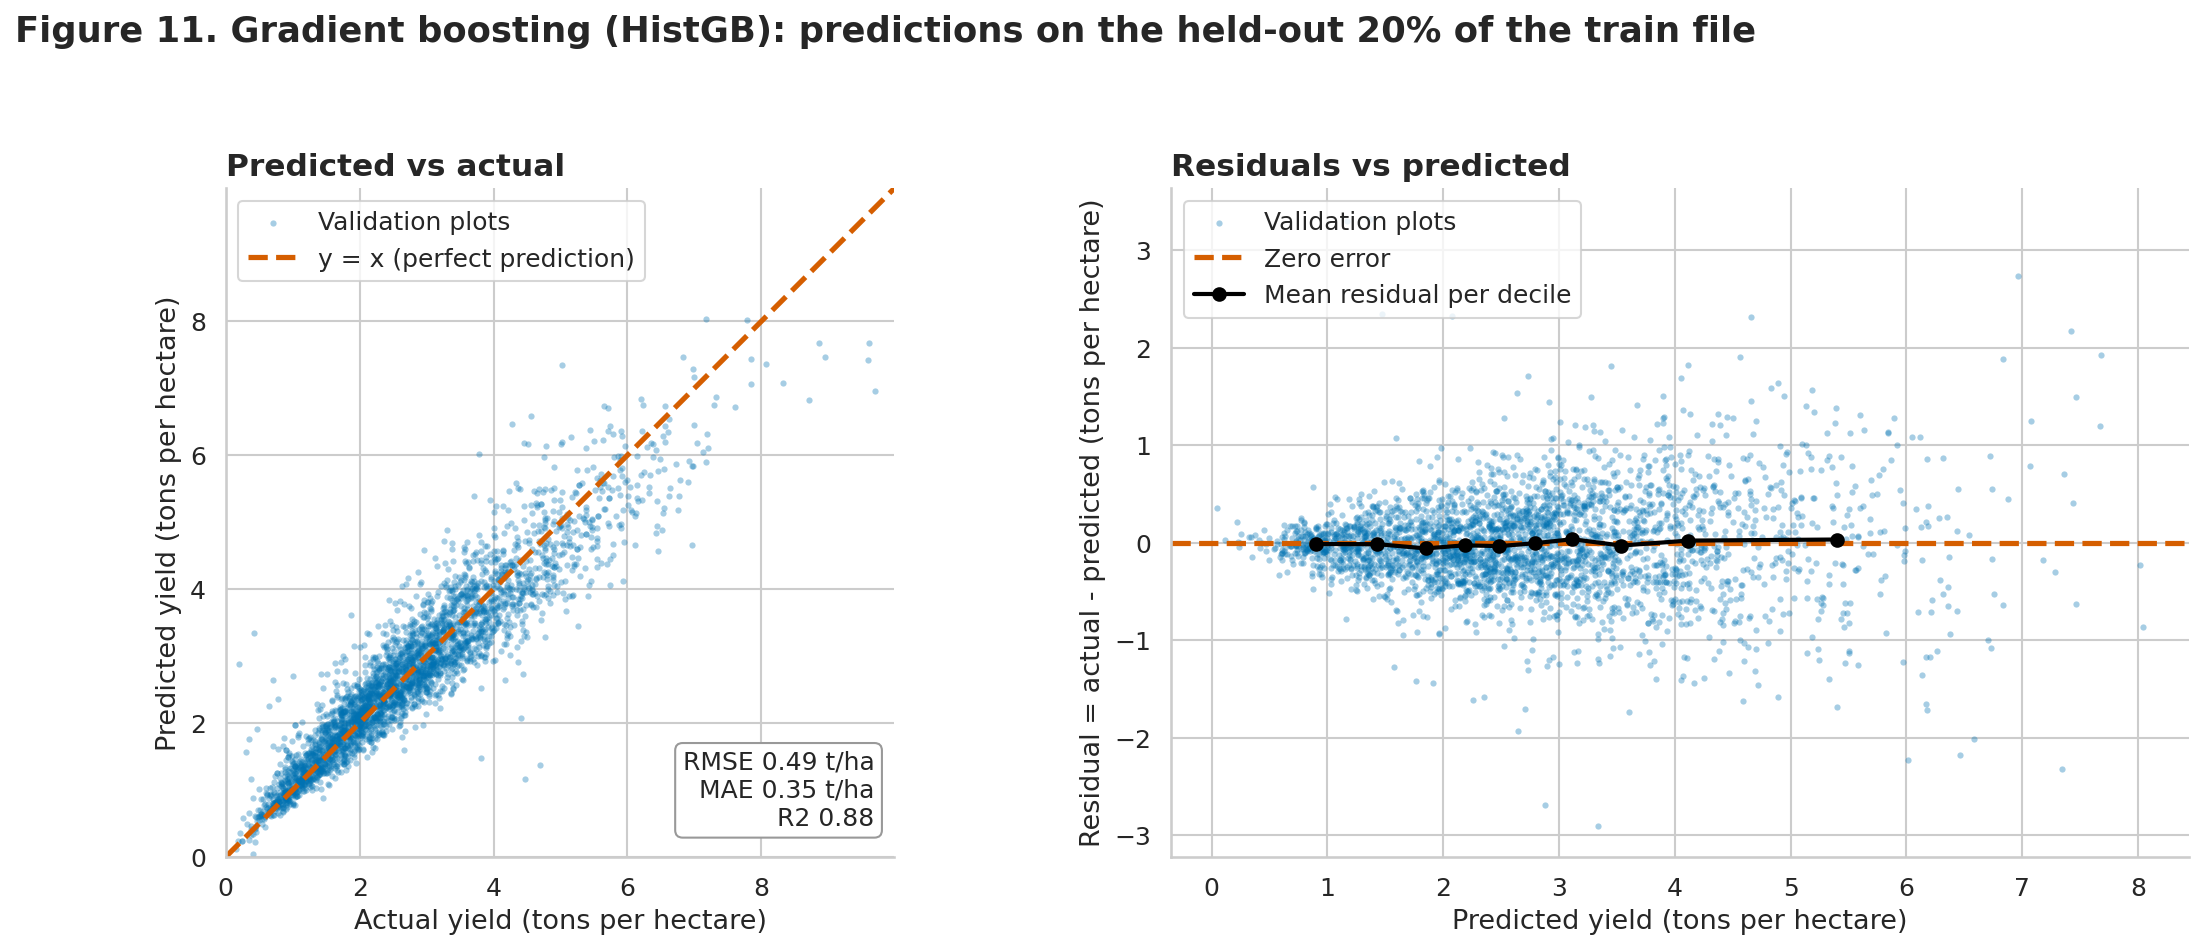

In [15]:
pred_va = best_pipe.predict(X_va)
resid = y_va - pred_va
rmse = mean_squared_error(y_va, pred_va) ** 0.5
mae = np.mean(np.abs(resid))
r2 = r2_score(y_va, pred_va)
lim = max(y_va.max(), pred_va.max()) * 1.03

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
ax1.scatter(y_va, pred_va, s=9, alpha=0.35, color="#0072B2", linewidths=0, label="Validation plots")
ax1.plot([0, lim], [0, lim], color="#D55E00", lw=2.5, ls="--", label="y = x (perfect prediction)")
ax1.set_xlim(0, lim); ax1.set_ylim(0, lim); ax1.set_aspect("equal")
ax1.set_xlabel("Actual yield (tons per hectare)"); ax1.set_ylabel("Predicted yield (tons per hectare)")
ax1.set_title("Predicted vs actual", loc="left"); ax1.legend(loc="upper left")
ax1.text(0.97, 0.04, f"RMSE {rmse:.2f} t/ha\nMAE {mae:.2f} t/ha\nR2 {r2:.2f}", transform=ax1.transAxes, ha="right", va="bottom", fontsize=12, bbox=dict(boxstyle="round", fc="white", ec="#999"))

ax2.scatter(pred_va, resid, s=9, alpha=0.35, color="#0072B2", linewidths=0, label="Validation plots")
ax2.axhline(0, color="#D55E00", lw=2.5, ls="--", label="Zero error")
bins = pd.qcut(pd.Series(pred_va), 10)
trend = pd.DataFrame({"pred": pred_va, "resid": resid.values}).groupby(bins, observed=True).mean()
ax2.plot(trend.pred, trend.resid, color="black", marker="o", lw=2, label="Mean residual per decile")
ax2.set_xlabel("Predicted yield (tons per hectare)"); ax2.set_ylabel("Residual = actual - predicted (tons per hectare)")
ax2.set_title("Residuals vs predicted", loc="left"); ax2.legend(loc="upper left")
fig.suptitle(f"Figure 11. {best_name}: predictions on the held-out 20% of the train file", fontsize=17, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_fig(fig, "fig11_predicted_vs_actual_residuals.png")
print(f"RMSE {rmse:.3f} | MAE {mae:.3f} | R2 {r2:.3f} | mean residual {resid.mean():.3f}")
print("Residual spread by predicted-yield decile (SD):", pd.DataFrame({"p": pred_va, "r": resid.values}).groupby(bins, observed=True).r.std().round(2).tolist())
print("Residual deciles mean:", trend.resid.round(2).tolist())

## Figure 12 · Permutation feature importance

saved ../figures/fig12_feature_importance.png  (1803 px wide)
             feature  importance    sd  weather_derived
           crop_type       0.950 0.018            False
          altitude_m       0.747 0.018            False
  season_mean_temp_c       0.481 0.012             True
   pest_disease_flag       0.238 0.008            False
  soil_quality_index       0.159 0.005            False
fert_x_improved_seed       0.112 0.004            False
              region       0.077 0.004            False
fertilizer_kg_per_ha       0.076 0.004            False
  rainfall_mm_season       0.027 0.004            False
  improved_seed_used       0.010 0.001            False

Weather-derived features, share of total importance: 17.0 %


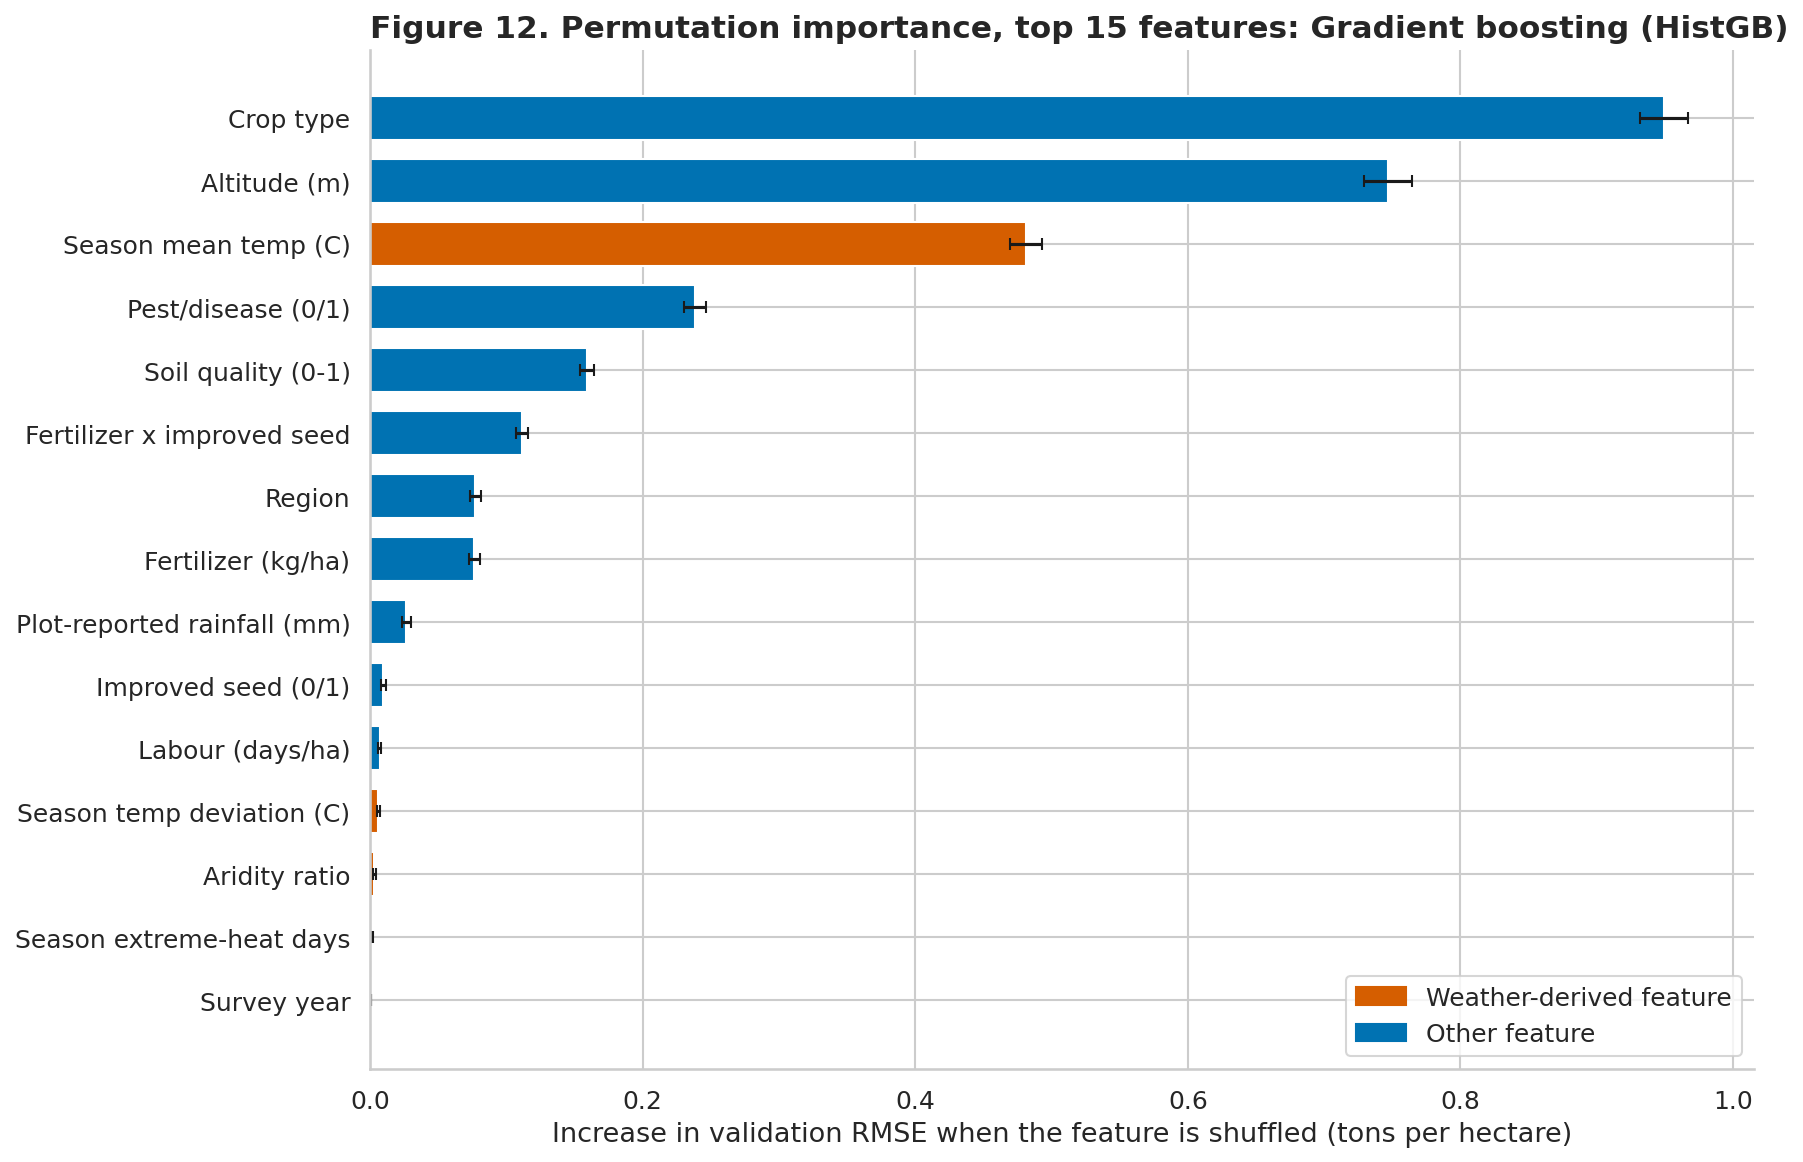

In [16]:
perm = permutation_importance(best_pipe, X_va, y_va, n_repeats=10, random_state=42, scoring="neg_root_mean_squared_error", n_jobs=1)
imp = pd.DataFrame({"feature": X_va.columns, "importance": perm.importances_mean, "sd": perm.importances_std}).sort_values("importance", ascending=False)
imp["weather_derived"] = imp.feature.isin(WEATHER_DERIVED)
imp.to_csv("../reports/C_permutation_importance.csv", index=False)

top = imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh([NICE[f] for f in top.feature], top.importance, xerr=top.sd, color=[C_WEATHER if w else C_OTHER for w in top.weather_derived], capsize=3, height=0.7)
ax.set_xlabel("Increase in validation RMSE when the feature is shuffled (tons per hectare)")
ax.set_ylabel("")
ax.legend(handles=[Patch(color=C_WEATHER, label="Weather-derived feature"), Patch(color=C_OTHER, label="Other feature")], loc="lower right")
ax.set_title(f"Figure 12. Permutation importance, top 15 features: {best_name}", loc="left")
fig.tight_layout()
save_fig(fig, "fig12_feature_importance.png")
print(imp.head(10).round(3).to_string(index=False))
print("\nWeather-derived features, share of total importance:", round(imp[imp.weather_derived].importance.sum() / imp.importance.clip(lower=0).sum() * 100, 1), "%")

## Captions · `figures/figure_captions.md`
One or two sentences per figure: what it shows, then the "so what". All numbers are computed from the objects above.

In [17]:
n_cols = sum(len(t) for t in miss.values())
n_bad = sum(int(((t.missing_pct + t.sentinel_pct) > 0).sum()) for t in miss.values())
worst_pct, worst_col = max((r.missing_pct + r.sentinel_pct, r.column) for t in miss.values() for r in t.itertuples())

yc = "yield_tons_per_ha"
corr_y = corr[yc]
clim_mean = climate.groupby("region")[["avg_temp_c", "monthly_rainfall_mm"]].mean()
others = clim_mean.drop("Somali")
peak_months = climate.loc[climate.groupby("region").monthly_rainfall_mm.idxmax()].month_num
pct_price = ((price_year[2024] / price_year[2021] - 1) * 100).sort_values(ascending=False)
top_price_each_year = {y: price_year[y].idxmax() for y in price_year.columns}
top_by_region = rev.idxmax()
base_row = results[results.model.str.startswith("Mean")].iloc[0]
hgb = results[results.model == best_name].iloc[0]
rf_row = results[results.model == "Random forest"].iloc[0]
ridge_row = results[results.model.str.startswith("Ridge")].iloc[0]
q = pd.qcut(pd.Series(pred_va), 10)
sd_dec = pd.DataFrame({"p": pred_va, "r": resid.values}).groupby(q, observed=True).r.std()
w_imp = imp[imp.weather_derived].sort_values("importance", ascending=False)
share_w = imp[imp.weather_derived].importance.sum() / imp.importance.clip(lower=0).sum() * 100
b = binned_all

captions = {
"fig01_missingness.png": f"Share of empty cells and -999 codes in each of the {n_cols} raw columns across the plot, weather and price tables. {n_bad} columns are affected (worst: {worst_col}, {worst_pct:.1f}% of rows), so no column is badly broken, but the -999 codes in particular would silently distort averages if left in.",
"fig02_before_after_cleaning.png": f"Box plots of raw versus cleaned values: farm size reached {train_raw.farm_size_ha.max():.0f} ha and fertilizer {train_raw.fertilizer_kg_per_ha.max():.0f} kg/ha, labour contained a -999 code, and some prices were {prices_raw.price_birr_per_quintal.min():.0f} birr (per kg, not per quintal). After capping, NaN handling and unit repair the ranges are up to {df.farm_size_ha.max():.0f} ha, {df.fertilizer_kg_per_ha.max():.0f} kg/ha, {df.labor_days_per_ha.min():.0f}-{df.labor_days_per_ha.max():.0f} labour days and {prices_clean.price_birr_per_quintal.min():,.0f}-{prices_clean.price_birr_per_quintal.max():,.0f} birr, so the bulk of the data is now readable.",
"fig03_yield_distribution.png": f"Yield is right-skewed overall (mean {df[yc].mean():.2f} vs median {df[yc].median():.2f} t/ha), and the crop violins show maize clearly highest (median {df[df.crop_type=='maize'][yc].median():.2f}) and teff lowest ({df[df.crop_type=='teff'][yc].median():.2f}). Crop type clearly shifts the whole distribution, and maize and wheat are the most variable crops (SD {df[df.crop_type=='maize'][yc].std():.2f} and {df[df.crop_type=='wheat'][yc].std():.2f} t/ha).",
"fig04_region_crop_heatmap.png": f"Mean yield for every region and crop pair, with plot counts ({counts.values.min()} to {counts.values.max()} per cell, all large enough to trust). SNNPR maize is best ({pivot.stack().max():.2f} t/ha) and Somali teff worst ({pivot.stack().min():.2f}); Somali is lowest for every crop, so both the region and the crop-region pairing matter.",
"fig05_correlation_heatmap.png": f"Pairwise correlations between yield, the plot features and the weather-derived features (orange labels). The weather features correlate most strongly with yield (extreme-heat days {corr_y['season_extreme_heat_days']:.2f}, season temperature {corr_y['season_mean_temp_c']:.2f}, station rainfall {corr_y['season_rain_total_mm']:+.2f}) while distance to market ({corr_y['distance_to_market_km']:+.2f}) and plot-reported rainfall ({corr_y['rainfall_mm_season']:+.2f}) show almost none; the weather features also overlap heavily with each other, partly because the hot Somali region drives all of them.",
"fig06_climate_by_region.png": f"Monthly mean temperature and rainfall for each region, with the growing seasons for a February (Feb-May) and a June (Jun-Sep) planting shaded. Somali is hot ({clim_mean.loc['Somali','avg_temp_c']:.1f} C) and dry ({clim_mean.loc['Somali','monthly_rainfall_mm']:.0f} mm per month) while the others average {others.avg_temp_c.min():.1f}-{others.avg_temp_c.max():.1f} C, and every region's wettest month falls inside the Jun-Sep window, so planting month changes how much of the rains a crop catches.",
"fig07_yield_vs_season_temp.png": f"Plot-level yield against growing-season mean temperature for each crop, with binned means and 95% intervals. Crops do have different sweet spots: maize peaks near {b['maize'].temp[b['maize'].mean_yield.idxmax()]:.0f} C ({b['maize'].mean_yield.max():.1f} t/ha) and sorghum near {b['sorghum'].temp[b['sorghum'].mean_yield.idxmax()]:.0f} C, while barley, wheat and teff do best in the coolest seasons (about 16-18 C) and fall steadily as it gets hotter; temperature is strongly tied to region here, so this is an association, not a controlled test.",
"fig08_price_trends.png": f"Average price per quintal for each crop from 2021 to 2024 (left) and indexed to 2021 = 100 (right). Every crop rose by more than 20% (from {pct_price.index[0]} +{pct_price.iloc[0]:.1f}% to {pct_price.index[-1]} +{pct_price.iloc[-1]:.1f}%), and {top_price_each_year[2024]} stays the highest-priced crop in every year, so the growth gap changes budgets but not the ranking.",
"fig09_revenue_by_crop_region.png": f"Mean revenue per hectare (yield x 10 x price) for each crop in each region, bars starting at zero. The most profitable crop is {top_by_region['Oromia']} in Oromia, SNNPR and Tigray, {top_by_region['Amhara']} in Amhara and {top_by_region['Somali']} in Somali, and Somali revenues ({rev['Somali'].min():.0f}-{rev['Somali'].max():.0f} thousand birr/ha) are far below the other regions ({rev.drop(columns='Somali').min().min():.0f}-{rev.drop(columns='Somali').max().max():.0f}), so the best crop depends on where the farm is.",
"fig10_model_comparison.png": f"Validation RMSE of each model (bars) with 5-fold cross-validation mean and spread (dots) and the mean-predictor baseline (dashed line). {best_name} is best at {hgb.val_rmse:.3f} t/ha versus {base_row.val_rmse:.3f} for the baseline ({(1 - hgb.val_rmse / base_row.val_rmse) * 100:.0f}% lower), ahead of the random forest ({rf_row.val_rmse:.3f}) and ridge ({ridge_row.val_rmse:.3f}), and its small CV spread (+/-{hgb.cv_rmse_std:.3f}) shows the ranking is stable.",
"fig11_predicted_vs_actual_residuals.png": f"Left: predicted versus actual yield on the held-out 20% with the y = x line; right: residuals versus predicted yield. Predictions track the line well (R2 {r2:.2f}, RMSE {rmse:.2f}, MAE {mae:.2f} t/ha) with no overall bias (mean residual {resid.mean():+.2f}), but the error grows with predicted yield (residual SD {sd_dec.iloc[0]:.2f} in the lowest decile to {sd_dec.iloc[-1]:.2f} in the highest), so high-yield plots are the least certain.",
"fig12_feature_importance.png": f"Permutation importance (increase in validation RMSE when a feature is shuffled) for the top 15 features, weather-derived features in orange. Crop type ({imp.importance.iloc[0]:.2f}), altitude ({imp[imp.feature=='altitude_m'].importance.iloc[0]:.2f}) and season mean temperature ({imp[imp.feature=='season_mean_temp_c'].importance.iloc[0]:.2f}, the top weather feature) lead, weather-derived features together carry {share_w:.0f}% of total importance, and plot-reported rainfall adds only {imp[imp.feature=='rainfall_mm_season'].importance.iloc[0]:.2f}.",
}
assert len(captions) == 12 and all(name.startswith(f"fig{i:02d}_") for i, name in enumerate(captions, start=1))
lines = ["# Figure captions", "", "Each caption says what the figure shows and the takeaway. Figures 10-12 use a quick model trained on the train file only (see notebook 03); the full modeling write-up is Deliverable D.", ""]
for name, text in captions.items():
    lines += [f"**{name}** - {text}", ""]
open(f"{FIG_DIR}/figure_captions.md", "w").write("\n".join(lines))
print(open(f"{FIG_DIR}/figure_captions.md").read())

# final check: all 12 files exist and are wide enough
for name in captions:
    assert plt.imread(f"{FIG_DIR}/{name}").shape[1] >= 1200, name
print("All 12 figures present, each at least 1200 px wide.")

# Figure captions

Each caption says what the figure shows and the takeaway. Figures 10-12 use a quick model trained on the train file only (see notebook 03); the full modeling write-up is Deliverable D.

**fig01_missingness.png** - Share of empty cells and -999 codes in each of the 25 raw columns across the plot, weather and price tables. 8 columns are affected (worst: fertilizer_kg_per_ha, 5.0% of rows), so no column is badly broken, but the -999 codes in particular would silently distort averages if left in.

**fig02_before_after_cleaning.png** - Box plots of raw versus cleaned values: farm size reached 60 ha and fertilizer 899 kg/ha, labour contained a -999 code, and some prices were 34 birr (per kg, not per quintal). After capping, NaN handling and unit repair the ranges are up to 5 ha, 163 kg/ha, 5-105 labour days and 2,403-8,811 birr, so the bulk of the data is now readable.

**fig03_yield_distribution.png** - Yield is right-skewed overall (mean 2.76 vs median 2.58 t/ha), and th